<div style="text-align: center; padding-top: 12%;">

# Support Vector Machine

## DATA 301 @ WM

<figure class="no-fragment">
<center>
<a href="https://github.com/yanhai-xiong/DATA301-AML/blob/main/Module%203%20-%20Supervised%20Learning%20-%20Regression%20and%20Classification%20Problems/Section%203.1%20-%20Support%20Vector%20Machines.ipynb" target="_blank">
    <img class="no-fragment"
         src="https://brand.github.com/_next/static/media/logo-03.cc5e5332.png"
         width="80px"/>
</a>
</center>
</figure>
</div>

> How can we classify by finding a **robust** separating boundary?

Support Vector Machines Seminal Paper (1992): http://www.svms.org/training/BOGV92.pdf

## <font color='blue' size=6pt>Support Vector Machines (SVM)</font>

So far, we have studied two major supervised learning problems:
- **Regression** — predict a continuous value (**linear regression**)
- **Classification** — predict a discrete class (**logistic regression**, **decision trees**, and **random forests**)

Now consider a different way to think about classification:
> If many decision boundaries can correctly separate two classes, **which boundary should we choose?**

Support Vector Machines (SVMs) answer this question using a geometric principle:
> **Choose the decision boundary that provides the largest separation, or margin, between the classes.**

SVM is actually a broader framework for supervised learning:
$$
\boxed{
\text{Support Vector Methods}
\begin{cases}
\text{SVC} & \rightarrow \text{Classification}\\
\text{SVR} & \rightarrow \text{Regression}
\end{cases}}
$$

We will begin with **classification**, where the geometric intuition is easiest to see, and return to **Support Vector Regression (SVR)** at the end.

### <font color='blue' size=5pt>Which Decision Boundary Should We Choose?</font>

<figure  class = "no-fragment">
<center>
<img src='https://quantsignals.files.wordpress.com/2012/09/linearkernel.jpeg?w=584'
width='300px' /></center>
</figure>

Consider a binary classification problem with two classes and suppose the two classes are **linearly separable**. For example, in 2D, a linear decision boundary can be written as
$$
w^T \mathbf{x}+b=0 \quad \text{ or }\quad  w_1x_1+w_2x_2+b=0.
$$
- What if many boundaries can achieve **100% training accuracy**?
- Are they equally good?

SVM introduces an additional criterion:
> Among all separating boundaries, choose the one that stays **as far away from the training observations as possible**, i.e., maximize the **margin**.

### <font color='blue' size=5pt>The SVM Decision Function</font>
<figure class = "no-fragment">
<center>
<img src='https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcThIY8B-Z8rdAQezPkw9mDvD0vXR4pDStQPSjh6TnN6rdtSJKxNTk6JhSk&s=10'
width='300px' /></center>
</figure>

For a linear SVM, define the decision function $f(x)=w^Tx+b.$
- $w^Tx+b=0 $ defines the **decision boundary**
- $w$ determines the **orientation** of the boundary
- $b$ determines its **position**
- $|w^Tx+b|$ the **magnitude** tells us something about how far an observation is from the decision boundary

#### Sign of $f(x)$ 
The sign of $f(x)$ determines the predicted class:
$$
\hat y =
\begin{cases}
+1, & w^Tx+b > 0,\\
-1, & w^Tx+b < 0.
\end{cases}
$$

### <font color='blue' size=5pt>Distance to the Decision Boundary</font>

The perpendicular distance from a point $x$ to the hyperplane
$$
w^Tx+b=0
$$
is
$$
\boxed{
d(x)=\frac{|w^Tx+b|}{\|w\|}
}
$$
- $\|w\|=\sqrt{w_1^2+w_2^2+\cdots+w_p^2}$

Therefore, SVM does not only ask whether an observation is on the correct side of the boundary.
It also asks:

> **How far is the observation from the boundary?** $\rightarrow$ The **margin**.

### <font color='blue' size=5pt>The Maximum-Margin Classifier</font>

For linearly separable data, we can scale $w$ and $b$ so that all correctly classified observations satisfy
$$
y_i(w^Tx_i+b)\geq 1.
$$

The two margin boundaries are
$$
w^Tx+b=+1 
\quad \text{and} \quad
w^Tx+b=-1.
$$

The distance between these two boundaries is ${\frac{2}{\|w\|}}.$
Therefore, **maximizing the margin** is equivalent to **minimizing $\|w\|$**.

The hard-margin SVM optimization problem becomes
$$
\boxed{
\begin{aligned}
\min_{w,b}\quad & \frac{1}{2}\|w\|^2\\
\text{subject to}\quad & y_i(w^Tx_i+b)\geq1,\qquad i=1,\ldots,n.
\end{aligned}}
$$



### <font color='blue' size=5pt>Support Vectors</font>

Not every training observation is equally important for determining the SVM decision boundary.
The observations closest to the boundary are called **support vectors**.

For a hard-margin SVM, they lie on the margin:
$$
y_i(w^Tx_i+b)=1
$$
and effectively **support** the optimal separating hyperplane.

A key property of SVM is:
> Moving observations far away from the margin usually does not change the decision boundary. But moving a support vector can change it substantially.

Therefore, the SVM solution is primarily determined by a subset of the training data - $ {\text{Support Vectors}}$

## <font color='blue' size=5pt>What If the Data Are Not Perfectly Separable?</font>

<figure  class = "no-fragment">
<center>
<img src='https://machinelearningsite.com/wp-content/uploads/2024/11/Soft-Margin-SVM-edited.png'
width='400px' />
</center>
</figure>

The hard-margin classifier assumes that $
y_i(w^Tx_i+b)\geq1
$
for **every** training observation.

Instead of requiring perfect separation, we have **soft-margin SVM** that allows some observations to:
- enter the margin, or
- even appear on the wrong side of the decision boundary.

### <font color='blue' size=5pt>Soft-Margin SVM</font>

Introduce a **slack variable** $\xi_i\geq0$ for each observation:
$
y_i(w^Tx_i+b)\geq1-\xi_i.
$

The optimization problem becomes
$$
\boxed{
\begin{aligned}
\min_{w,b,\xi}\quad
&\frac{1}{2}\|w\|^2
+C\sum_{i=1}^{n}\xi_i\\
\text{subject to}\quad
&y_i(w^Tx_i+b)\geq1-\xi_i,\\
&\xi_i\geq0.
\end{aligned}}
$$
- The slack variable tells us how much an observation violates the margin:
    - $\xi_i=0$: correctly classified and on/outside the margin
    - $0<\xi_i<1$: correctly classified but **inside the margin**
    - $\xi_i=1$: on the decision boundary
    - $\xi_i>1$: **misclassified**
- The parameter $C$ controls how strongly we penalize these violations.

> Typically solved through its dual formulation.

### <font color='blue' size=5pt>The Regularization Parameter $C$</font>

The parameter $C$ controls the trade-off between:

1. having a **large margin**, and
2. avoiding **training errors / margin violations**.

$$
\boxed{
\text{Large }C \rightarrow \text{margin violations}
\qquad
\text{Small }C \rightarrow \text{large margin}
}
$$

> SVM does not only care about getting the class correct — it also wants the prediction to be sufficiently far from the decision boundary.

#### Large $C$

Margin violations are expensive.

$$
C\uparrow
\quad\Rightarrow\quad
\text{stronger penalty for violations}
$$

The model tends to fit the training data more closely, potentially producing a **smaller margin**.

#### Small $C$

Margin violations are less expensive.

$$
C\downarrow
\quad\Rightarrow\quad
\text{more tolerance for violations}
$$

The model can choose a **wider margin**, potentially improving generalization.

In practice, $C$ is a **hyperparameter** that should be selected using validation or cross-validation.

### <font color='blue' size=5pt>Another View: Hinge Loss</font>

Soft-margin SVM can also be understood using the **hinge loss**:

$$
L_i=\max\left(0,\,1-y_i f(x_i)\right),
$$

where

$$
f(x_i)=w^Tx_i+b.
$$

Therefore,

$$
L_i=
\begin{cases}
0, & y_i f(x_i)\geq1,\\
1-y_i f(x_i), & y_i f(x_i)<1.
\end{cases}
$$

Notice something interesting:

An observation can be **correctly classified** but still have nonzero loss if it lies inside the margin.

This reflects an important difference between ordinary classification error and SVM:

> SVM does not only care about getting the class correct — it also wants the prediction to be sufficiently far from the decision boundary.

## <font color='blue' size=6pt>Nonlinear Support Vector Machines</font>

<figure  class = "no-fragment">
<center>
<img src='https://i.imgur.com/dLjN3r6.png'
width='400px' />
</center>
</figure>

What if the relationship is nonlinear?

> The data may not be linearly separable in the **original feature space**, but they may become linearly separable in a **higher-dimensional feature space**.

For example, imagine one class concentrated near the center and another class surrounding it.

No straight line can separate these classes well.

One possibility is to create new features.

For example,

$$
(x_1,x_2)
\quad\longrightarrow\quad
(x_1,x_2,x_1^2,x_2^2,x_1x_2).
$$

The data may not be linearly separable in the **original feature space**, but they may become linearly separable in a **higher-dimensional feature space**.

This is the key idea behind nonlinear SVM.

### <font color='blue' size=5pt>The Kernel Trick</font>

Suppose we transform the original input using
$
x\rightarrow\phi(x).
$
We could then train a linear SVM in the **transformed feature space**.

Instead of explicitly constructing $\phi(x)$, SVM uses **kernel function** to compute this quantity directly:
$$
\boxed{
K(x_i,x_j)=
\phi(x_i)^T\phi(x_j)
}
$$

Therefore,
$$
\boxed{
\text{Nonlinear boundary in original space}
\longleftrightarrow
\text{Linear boundary in transformed space}
}
$$

> A kernel lets SVM measure similarity as if the observations had been transformed into a higher-dimensional feature space, without actually computing that transformation.

### <font color='green'>Self-Study: Why Does the Kernel Trick Work?</font>

The kernel trick comes from the **dual formulation** of the SVM optimization problem.

For a hard-margin SVM in a transformed feature space $\phi(x)$, we solve
$$
\min_{w,b}\frac{1}{2}\|w\|^2
$$
subject to
$$
y_i\left(w^T\phi(x_i)+b\right)\geq 1.
$$

---

#### Step 1: Introduce Lagrange Multipliers

Introduce one multiplier $\alpha_i\geq0$ for each constraint:

$$
L(w,b,\alpha)=
\frac12\|w\|^2-
\sum_i\alpha_i
\left[
y_i(w^T\phi(x_i)+b)-1
\right].
$$

At the optimum,

$$
\frac{\partial L}{\partial w}=0.
$$

Therefore,

$$
w-\sum_i\alpha_i y_i\phi(x_i)=0,
$$

which gives

$$
\boxed{
w=\sum_i\alpha_i y_i\phi(x_i)
}
$$

This means that the optimal $w$ can be expressed as a **linear combination of the training observations in the transformed feature space**.

---

#### Step 2: Why Are They Called Support Vectors?

For most training observations,

$$
\alpha_i=0.
$$

Only certain observations have

$$
\alpha_i>0.
$$

These important observations are the **support vectors**.

Therefore,

$$
w=
\sum_{\text{support vectors}}
\alpha_i y_i\phi(x_i).
$$

The decision boundary is therefore determined primarily by the support vectors.

---

#### Step 3: From Support Vectors to Kernels

For a new observation $x$, the decision function is

$$
f(x)=w^T\phi(x)+b.
$$

Substituting the expression for $w$ gives

$$
f(x)=
\sum_i
\alpha_i y_i
\underbrace{\phi(x_i)^T\phi(x)}_{\text{inner product}}
+b.
$$

Notice that we never need $\phi(x)$ by itself.

We only need the inner product

$$
\phi(x_i)^T\phi(x).
$$

A **kernel function** computes this inner product directly:

$$
\boxed{
K(x_i,x)=\phi(x_i)^T\phi(x)
}
$$

so the prediction becomes

$$
\boxed{
f(x)=
\sum_i\alpha_i y_iK(x_i,x)+b.
}
$$

---

#### Key Takeaway

The kernel trick is possible because SVM can be formulated entirely in terms of **inner products between observations**:

$$
\boxed{
\text{SVM Optimization}
\rightarrow
w=\sum_i\alpha_i y_i\phi(x_i)
\rightarrow
\phi(x_i)^T\phi(x_j)
\rightarrow
K(x_i,x_j)
}
$$

Therefore, SVM can behave as if it were operating in a very high-dimensional feature space **without explicitly constructing the transformed features**.

> **Further study:** Lagrange multipliers, SVM dual formulation, KKT conditions, and the Representer Theorem.

### <font color='blue' size=5pt>Common Kernel Functions</font>

Several kernels are commonly used with SVM.

**Linear Kernel**
$$
K(x,z)=x^Tz
$$
Useful when the classes are approximately linearly separable.

**Polynomial Kernel**
$$
K(x,z)=(\gamma x^Tz+r)^d
$$
where $d$ controls the polynomial degree.

**Radial Basis Function (RBF) Kernel**
$$
K(x,z)=\exp\left(-\gamma\|x-z\|^2\right)
$$
- The RBF kernel is one of the most commonly used kernels.
- It allows SVM to construct highly nonlinear decision boundaries.
- Its behavior is controlled primarily by two hyperparameters: $
{C \text{ and } \gamma}
$

### <font color='blue' size=5pt>Self-Study: Understanding $\gamma$ in the RBF Kernel</font>

For the RBF kernel,

$$
K(x,z)=\exp(-\gamma\|x-z\|^2).
$$

The parameter $\gamma$ controls how quickly the similarity between two observations decreases with distance.

#### Small $\gamma$

Each training observation has a relatively **wide region of influence**.

The resulting decision boundary tends to be smoother.

#### Large $\gamma$

Each training observation has a more **local region of influence**.

The model can create more complex decision boundaries.

Therefore:

$$
\boxed{
\begin{array}{ccc}
\gamma\text{ small} &\rightarrow& \text{smoother boundary}\\
\gamma\text{ large} &\rightarrow& \text{more complex boundary}
\end{array}}
$$

For an RBF SVM, $C$ and $\gamma$ should usually be tuned **together** using cross-validation.

## <font color='blue' size=5pt>Important: Feature Scaling</font>

SVM is sensitive to the scale of the input features.

Therefore, features are usually standardized before fitting an SVM:
$$
x_j'=\frac{x_j-\mu_j}{\sigma_j}.
$$

A common workflow is
$$
\boxed{
\text{Standardize Features}
\rightarrow
\text{Train SVM}
\rightarrow
\text{Tune Hyperparameters}
}
$$

In `scikit-learn`, a `Pipeline` is particularly useful for combining scaling and SVM while avoiding data leakage during cross-validation.

Suppose we have two features:

$$
x_1=\text{age}\in[18,80]
$$

and

$$
x_2=\text{income}\in[20,000,200,000].
$$

Distance calculations would be dominated by income simply because it has a much larger numerical scale.

This is especially important for kernels such as the RBF kernel:

$$
K(x,z)=\exp(-\gamma\|x-z\|^2).
$$

## <font color='blue' size=5pt>Logistic Regression vs. SVM</font>

| | Logistic Regression | SVM |
|---|---|---|
| Main idea | Model class probability | Maximize classification margin |
| Typical loss | Log loss / cross-entropy | Hinge loss |
| Probability output | Natural | Not inherent |
| Important observations | All observations contribute | Mainly support vectors |
| Nonlinear extension | Feature engineering | Kernels |
| Regularization | Yes | Yes, controlled by $C$ |

Both logistic regression and SVM can construct linear decision boundaries, but they approach classification differently.

Conceptually:

$$
\boxed{
\text{Logistic Regression: learn }P(y|x)
}
$$

while SVM focuses on

$$
\boxed{
\text{SVM: find a robust separating boundary}
}
$$

Neither is universally better — the appropriate model depends on the data and the objective.

## <font color='blue' size=6pt>From SVM Classification to SVM Regression</font>

Instead of trying to separate classes, suppose we want to find a function
$$
f(x)=w^Tx+b
$$
that predicts a continuous target $y$.

Ordinary regression asks:
> **How close are the predictions to the observed values?**

Support Vector Regression asks a slightly different question:
> **Can we find a simple function such that most prediction errors are within an acceptable tolerance?**

This leads to **Support Vector Regression (SVR)**.

### <font color='blue' size=5pt>The $\epsilon$-Insensitive Tube</font>
<figure class = "no-fragment">
<center>
<img src='https://i.imgur.com/1dJCvHw.png'
width='300px' /></center>
</figure>

In SVR, we define a tolerance $\epsilon$ around the regression function:
$$
f(x)-\epsilon
\leq y
\leq
f(x)+\epsilon.
$$

This creates an **$\epsilon$-tube** around the prediction function.
The corresponding **$\epsilon$-insensitive loss** is
$$
\boxed{
L_\epsilon(y,f(x))=
\max\left(0,\ |y-f(x)|-\epsilon\right)
}
$$

So unlike MSE, SVR does **not** try to minimize every small prediction error.
Instead, it says:
> Errors smaller than $\epsilon$ are acceptable; focus on the observations that fall outside this tolerance.

### <font color='blue' size=5pt>Support Vector Regression: Optimization</font>

SVR balances two objectives:

1. Find a **simple / flat function**.
2. Penalize observations outside the $\epsilon$-tube.

$$
\boxed{
\text{SVR Objective}=
\text{Model Complexity}
+
C\times\text{Errors Outside the Tube}
}
$$

For SVR, the optimization can be written as
$$
\min_{w,b,\xi,\xi^*}
\frac{1}{2}\|w\|^2
+
C\sum_{i=1}^{n}(\xi_i+\xi_i^*)
$$
- $
y_i-f(x_i)\leq\epsilon+\xi_i,
$
- $
f(x_i)-y_i\leq\epsilon+\xi_i^*,
$
- $
\xi_i,\xi_i^*\geq0.
$

Observations outside or on the boundary of the $\epsilon$-tube determine the solution and become the **support vectors**.

### <font color='blue' size=5pt>Key Hyperparameters in SVR</font>

Three parameters are particularly important for RBF-based SVR:

$C$: **penalty strength**

Controls how strongly errors outside the $\epsilon$-tube are penalized.
- Large $C$ → stronger penalty for errors
- Small $C$ → more regularization

$\epsilon$: **tolerance**

Controls the width of the region in which errors receive no penalty.
- Large $\epsilon$ → wider tolerance tube
- Small $\epsilon$ → narrower tolerance tube

$\gamma$: **kernel locality**

For the RBF kernel,
$$
K(x,z)=\exp(-\gamma\|x-z\|^2).
$$
- Small $\gamma$ → smoother function
- Large $\gamma$ → more locally flexible function

Therefore,
$$
\boxed{
C,\quad \epsilon,\quad \gamma
}
$$
are commonly tuned using cross-validation.

## <font color='blue' size=5pt>Linear Regression vs. Support Vector Regression (SVR)</font>

| | Linear Regression | SVR |
|---|---|---|
| Main idea | Minimize prediction errors | Fit predictions within an $\epsilon$-tolerance tube |
| Typical loss | Squared error | $\epsilon$-insensitive loss |
| Small errors | Always penalized | Ignored if within $\epsilon$ |
| Important observations | All observations contribute | Mainly support vectors |
| Sensitivity to large errors | High with squared loss | Linear penalty outside $\epsilon$-tube |
| Nonlinear extension | Feature engineering / polynomial regression | Kernels |
| Regularization | Optional (Ridge/Lasso) | Built in, controlled by $C$ |
| Key hyperparameters | Depends on model | $C$, $\epsilon$, and kernel parameters such as $\gamma$ |

Both linear regression and SVR predict **continuous outcomes**, but they approach regression differently.

Conceptually, ordinary least squares tries to minimize

$$
\boxed{
\sum_i (y_i-f(x_i))^2
}
$$

so **every residual contributes to the objective**.

SVR instead uses the $\epsilon$-insensitive loss:

$$
\boxed{
L_\epsilon(y_i,f(x_i))=
\max(0,\ |y_i-f(x_i)|-\epsilon)
}
$$

so errors within the $\epsilon$-tube receive **no penalty**.

Therefore:

$$
\boxed{
\begin{array}{c}
\text{Linear Regression: minimize overall squared prediction error}\\[4pt]
\text{SVR: find a simple function while tolerating small errors}
\end{array}
}
$$

# Code Applications
---

### <font color='blue' size=5pt>SVM Classification with Scikit-Learn</font>

A typical SVM classification workflow is:

```python
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

model = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=1.0, gamma='scale')
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### <font color='blue' size=5pt>Support Vector Regression with Scikit-Learn</font>

The implementation of SVR is very similar to SVC:

```python
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

model = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### Setup

In [1]:
#@title
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore')

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, KFold
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import mean_squared_error as mse

### Variability in Data

In [12]:
# This method is to visualize the SVR results if we had 
# only one input feature and one dependent variable.
def svr_results(x, y, fitted_svr_model):

    print("C: {}".format(fitted_svr_model.C))
    print("Epsilon: {}".format(fitted_svr_model.epsilon))

    eps = fitted_svr_model.epsilon
    #print("Intercept: {:,.3f}".format(fitted_svr_model.intercept_[0]))
    #print("Coefficient: {:,.3f}".format(fitted_svr_model.coef_[0][0]))

    print("R2 = {:,.2f}".format(fitted_svr_model.score(x,y)))
    MSE = mse(y, fitted_svr_model.predict(x))
    print("MSE = {:,.2f}".format(MSE))

    perc_within_eps = 100*np.sum(np.abs(y.squeeze() - fitted_svr_model.predict(x))<eps)/len(y)
    print("Percentage within Epsilon = {:,.2f}%".format(perc_within_eps))

    # for meaningful plotting we need the x to be ordered
    #dat = np.column_stack([X_test,y_test])
    if x.shape[1] == 1:
        x = x[x[:,0].argsort(),:]
        yhat = fitted_svr_model.predict(x)
        xtest_one_feature_sorted = x
    else:
        xtest_sorted = x[x[:,0].argsort(),:]
        xtest_one_feature_sorted = xtest_sorted[:,0].reshape(-1,1)
        yhat = fitted_svr_model.predict(xtest_sorted)
    # Plot outputs
    fig, ax = plt.subplots(figsize=(8,4))
    #ax.set_xlim(-5, 5)
    #ax.set_ylim(-5, 5)
    ax.scatter(x[:,0], y,s=25,color='deepskyblue',ec='navy',alpha=0.5)
    ax.plot(xtest_one_feature_sorted, yhat, color='red',lw=2)
    ax.plot(xtest_one_feature_sorted, yhat+eps, linestyle='--',color='orange',lw=2)
    ax.plot(xtest_one_feature_sorted, yhat-eps, linestyle='--',color='orange',lw=2)
    ax.set_xlabel('Input',fontsize=14,color='darkgreen')
    ax.set_ylabel('Dependent',fontsize=14,color='darkgreen')
    ax.set_title('SVR Predictions',fontsize=16,color='purple')
    ax.grid(which='major', color ='grey', linestyle='-', alpha=0.8)
    ax.grid(which='minor', color ='grey', linestyle='--', alpha=0.2)
    ax.minorticks_on()

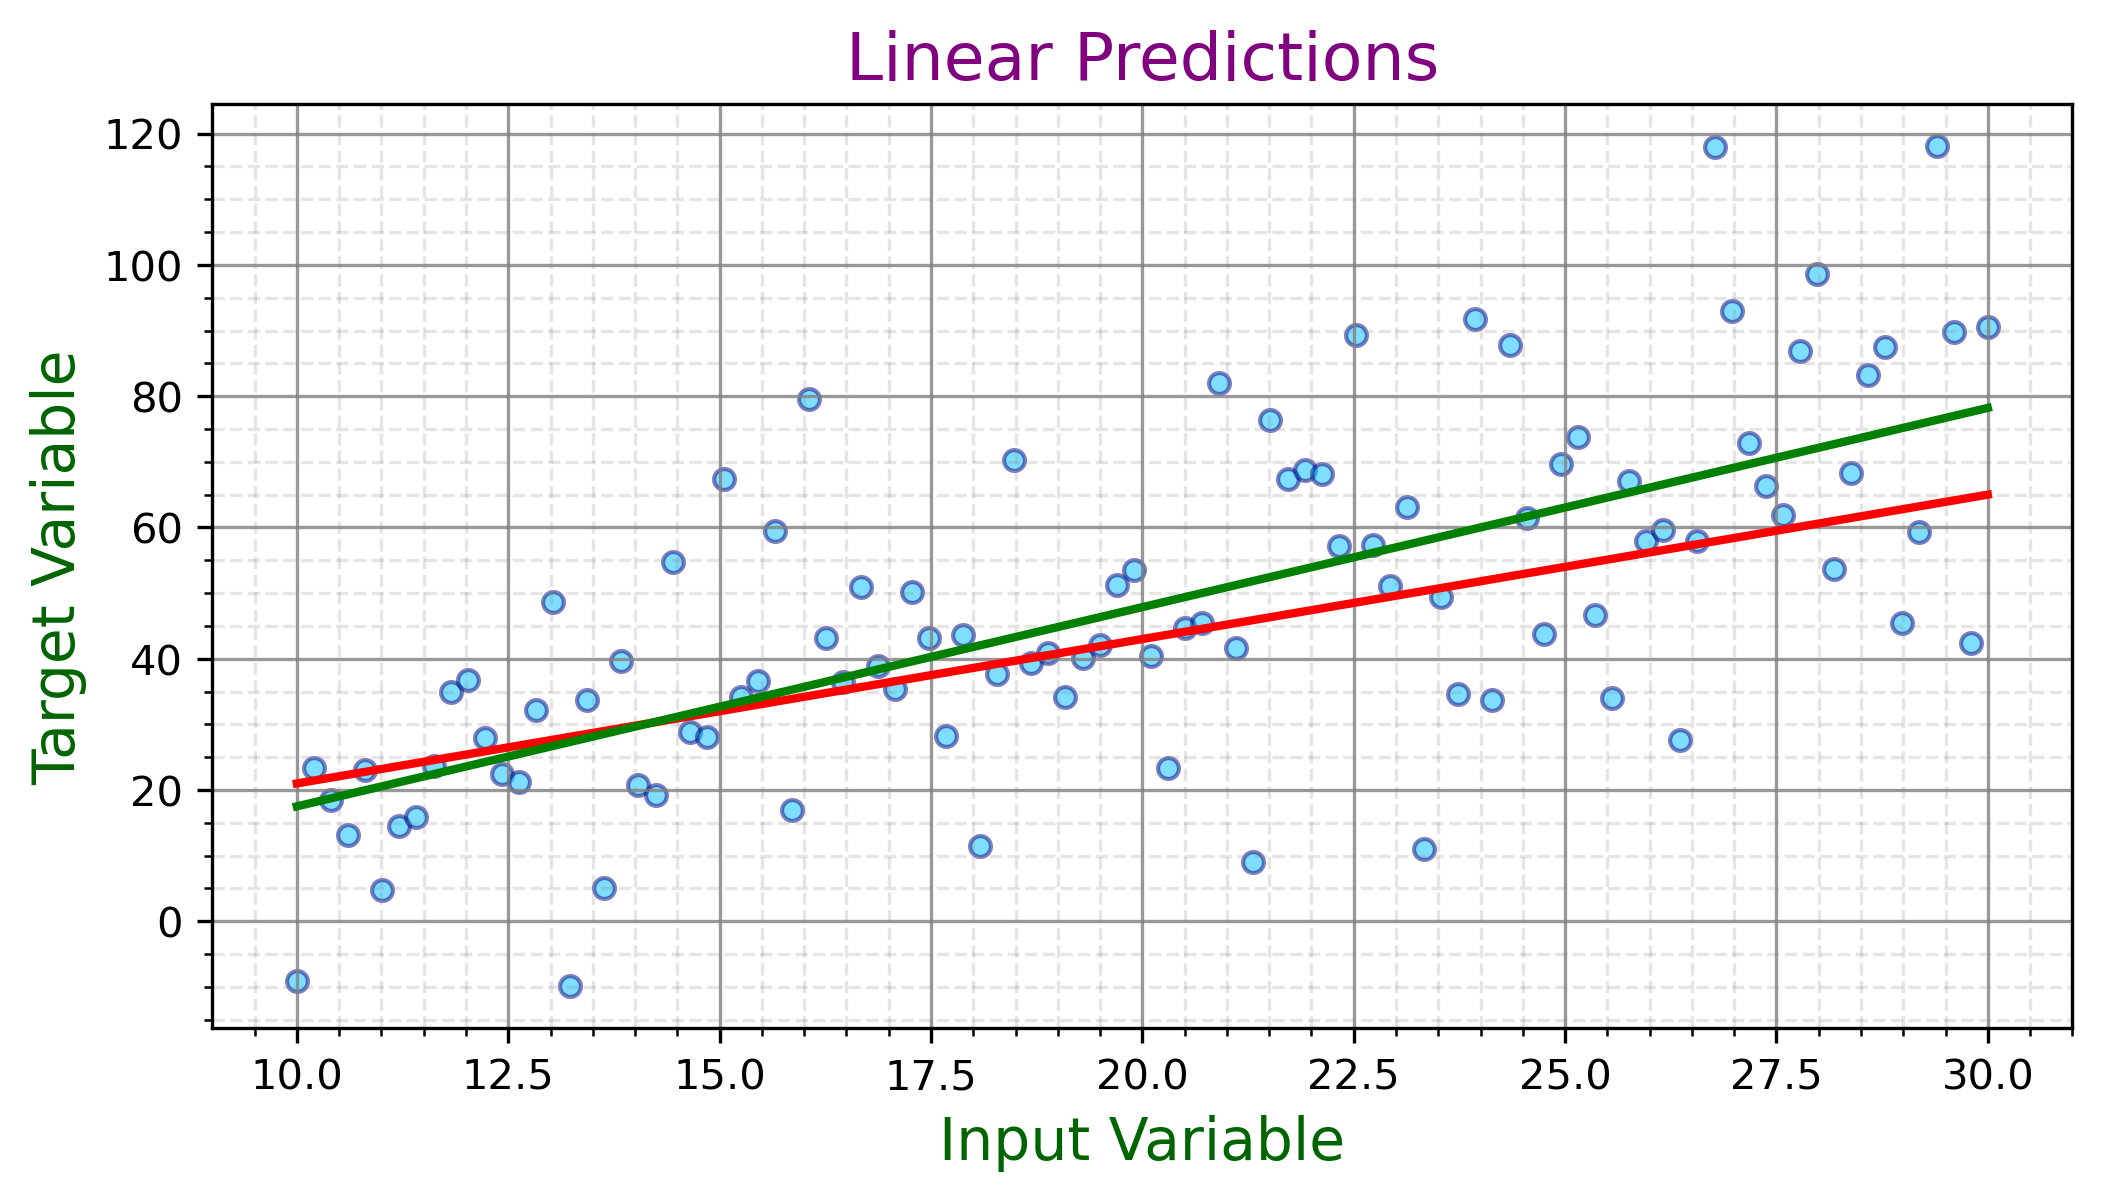

In [5]:
# example with fictitious data
# s is the standard deviation of the noise
s = 5 
x = np.linspace(10,30,100).reshape(-1,1)
# when the noise depends on the value of x, the problem is not going to be handled correctly by OLS, so we need SVR
y = 2.2*x-1 + x*np.random.normal(0,1,100).reshape(-1,1)
fig, ax = plt.subplots(figsize=(8,4))
#ax.set_xlim(-5, 5)
#ax.set_ylim(-5, 5)
model_linear = LinearRegression()
# model_linear = ElasticNet(alpha=0.1)
model_linear.fit(x,y)
yhat_linear = model_linear.predict(x)
ax.scatter(x, y,s=25,color='deepskyblue',ec='navy',alpha=0.5)
ax.plot(x, 2.2*x-1, color='red',lw=2)
ax.plot(x,yhat_linear,color = 'green',lw=2)
#ax.plot(xtest_one_feature_sorted, yhat+eps, linestyle='--',color='orange',lw=2)
#ax.plot(xtest_one_feature_sorted, yhat-eps, linestyle='--',color='orange',lw=2)
ax.set_xlabel('Input Variable',fontsize=14,color='darkgreen')
ax.set_ylabel('Target Variable',fontsize=14,color='darkgreen')
ax.set_title('Linear Predictions',fontsize=16,color='purple')
ax.grid(which='major', color ='grey', linestyle='-', alpha=0.8)
ax.grid(which='minor', color ='grey', linestyle='--', alpha=0.2)
ax.minorticks_on()
# plt.savefig('noise.png',dpi=300)

In [6]:
model_svr = SVR(epsilon=20,C=5,kernel='linear')
model_svr.fit(x,y)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",5
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",20
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [7]:
mse(y,model_svr.predict(x))

357.0190880900599

C: 5
Epsilon: 20
R2 = 0.47
MSE = 357.02
Percentage within Epsilon = 72.00%


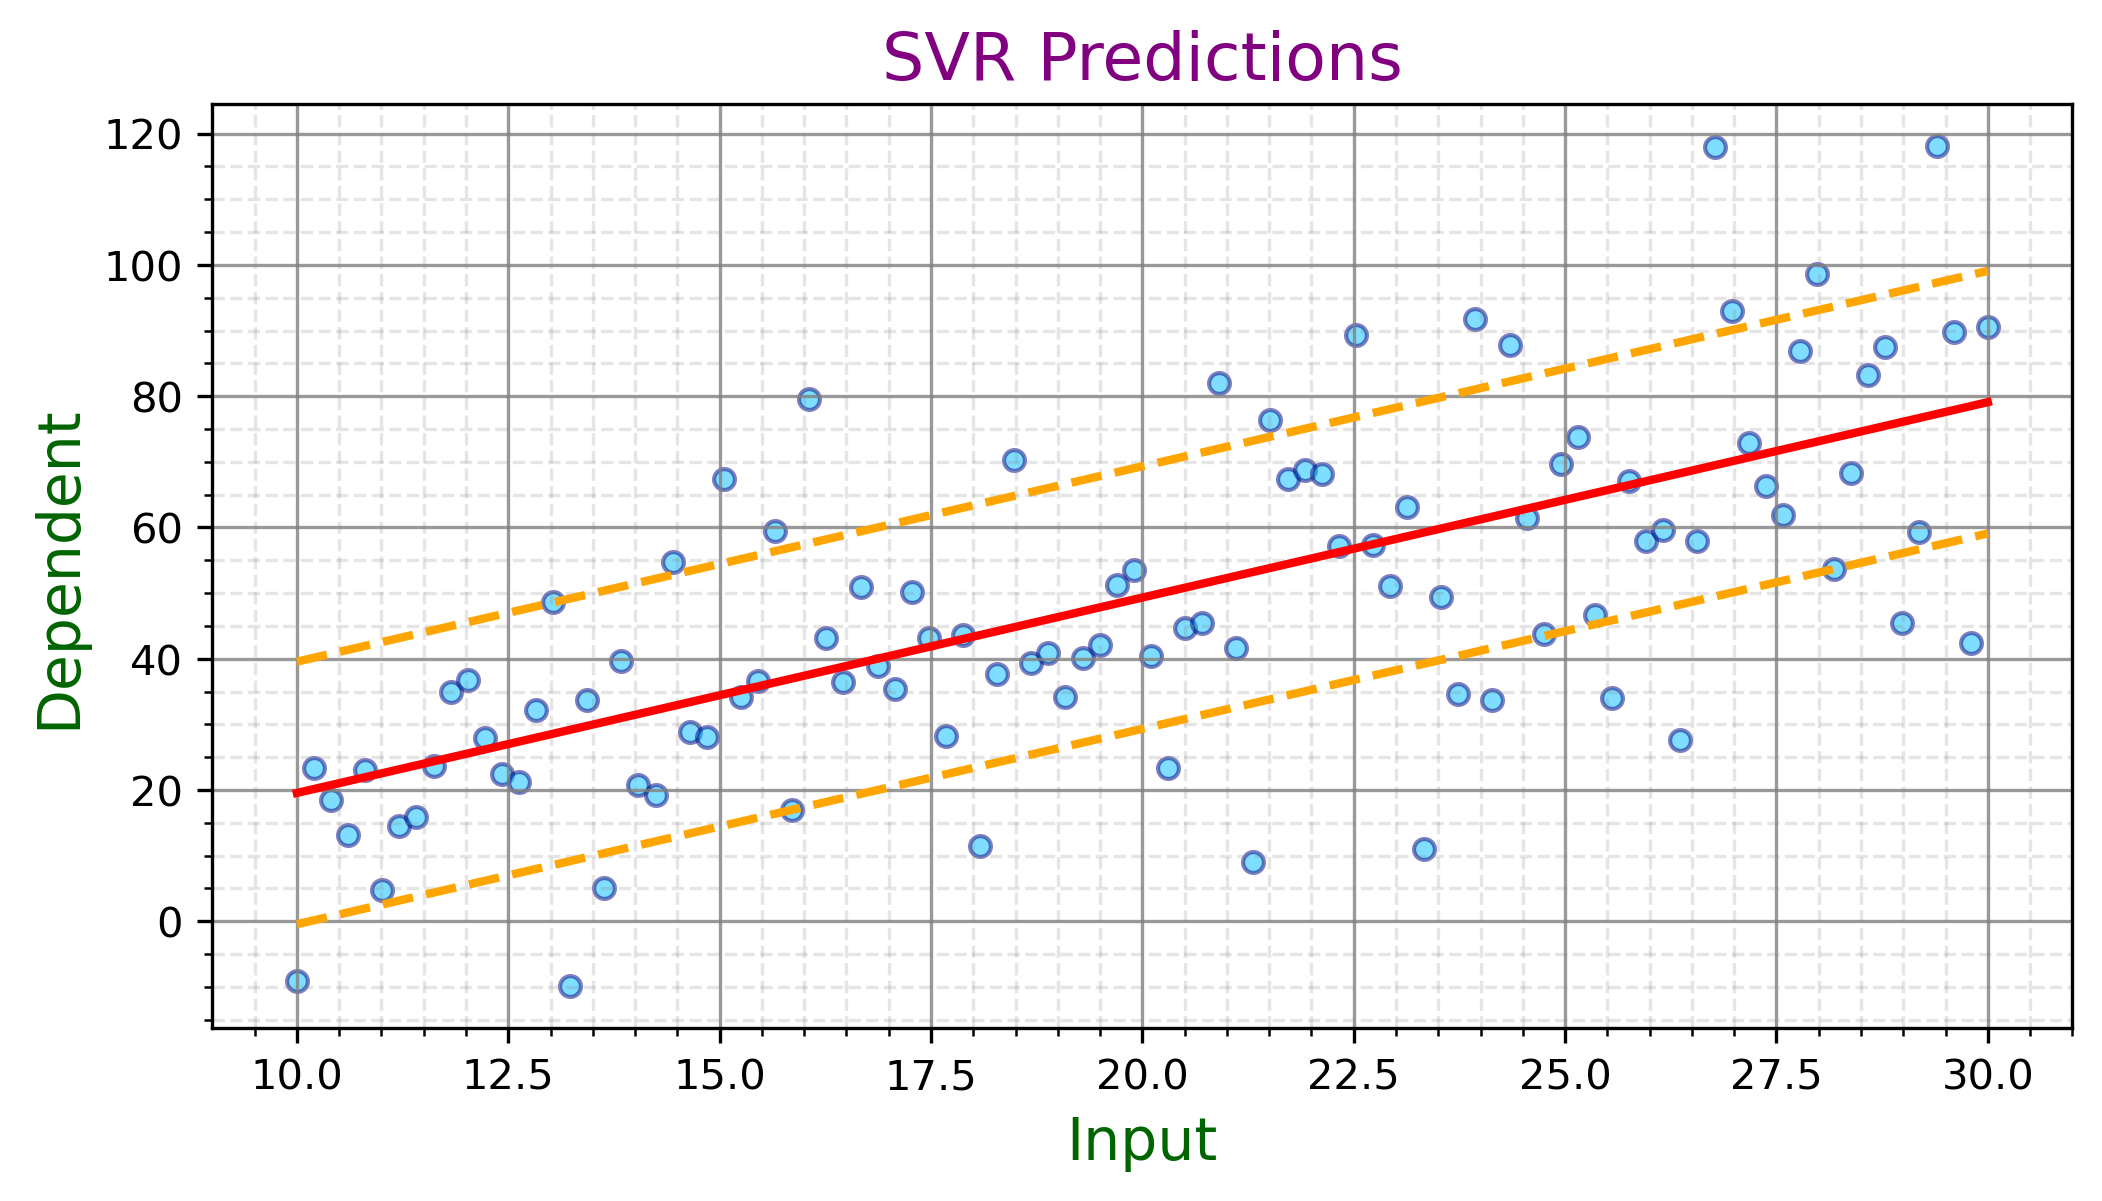

In [13]:
svr_results(x,y,model_svr)

### Real Data Application with SVR

In [14]:
data = pd.read_csv('https://github.com/yanhai-xiong/DATA301-AML/blob/main/Data%20Sets/concrete.csv?raw=true')

In [15]:
# here we just check what we got
data.head(3)

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27


In [16]:
X = data.loc[:,'cement'].values
y = data['strength'].values

In [23]:
# how to build indices for a k-fold cross-validation, or just one train_test_split 
ind = np.random.permutation(range(len(X)))
bins = np.array_split(ind,1//0.3)

In [28]:
len(ind)

1030

In [27]:
len(bins[0])

344

In [29]:
# this is an example of how to do a train/test/split from scratch
X = data.loc[:,'cement'].values
X_test = X[bins[0]]
y_test = y[bins[0]]
ind_train = np.delete(range(len(X)),bins[0])
X_train = X[ind_train]
y_train = y[ind_train]

In [30]:
X_train.shape

(686,)

In [31]:
scale = StandardScaler() # this is not needed unless we have more input features

In [32]:
if len(X_train.shape)==1:
  X_train = X_train.reshape(-1,1)
  X_test = X_test.reshape(-1,1)
else:
  X_train = scale.fit_transform(X_train)
  X_test = scale.transform(X_test)

In [39]:
# here we define a model based on SVR
# so we need to specify the hyper-parameters
eps = 10
model_svr2 = SVR(kernel='poly',degree=1,epsilon=eps,C=2)

In [41]:
# here we fit SVR on the whole data
model_svr2.fit(X_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",1
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",2
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",10
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [42]:
# evaluate the R2 on the test data
model_svr2.score(X_test,y_test)

0.19877158941690853

In [43]:
# why do we need a different set of variables?
# Answer: because we want to plot the band
xvals = X_test # xvals is in the range of the input feature
xvals = xvals[xvals[:,0].argsort(),:]
yh = model_svr2.predict(xvals)

C: 2
Epsilon: 10
R2 = 0.20
MSE = 208.80
Percentage within Epsilon = 49.42%


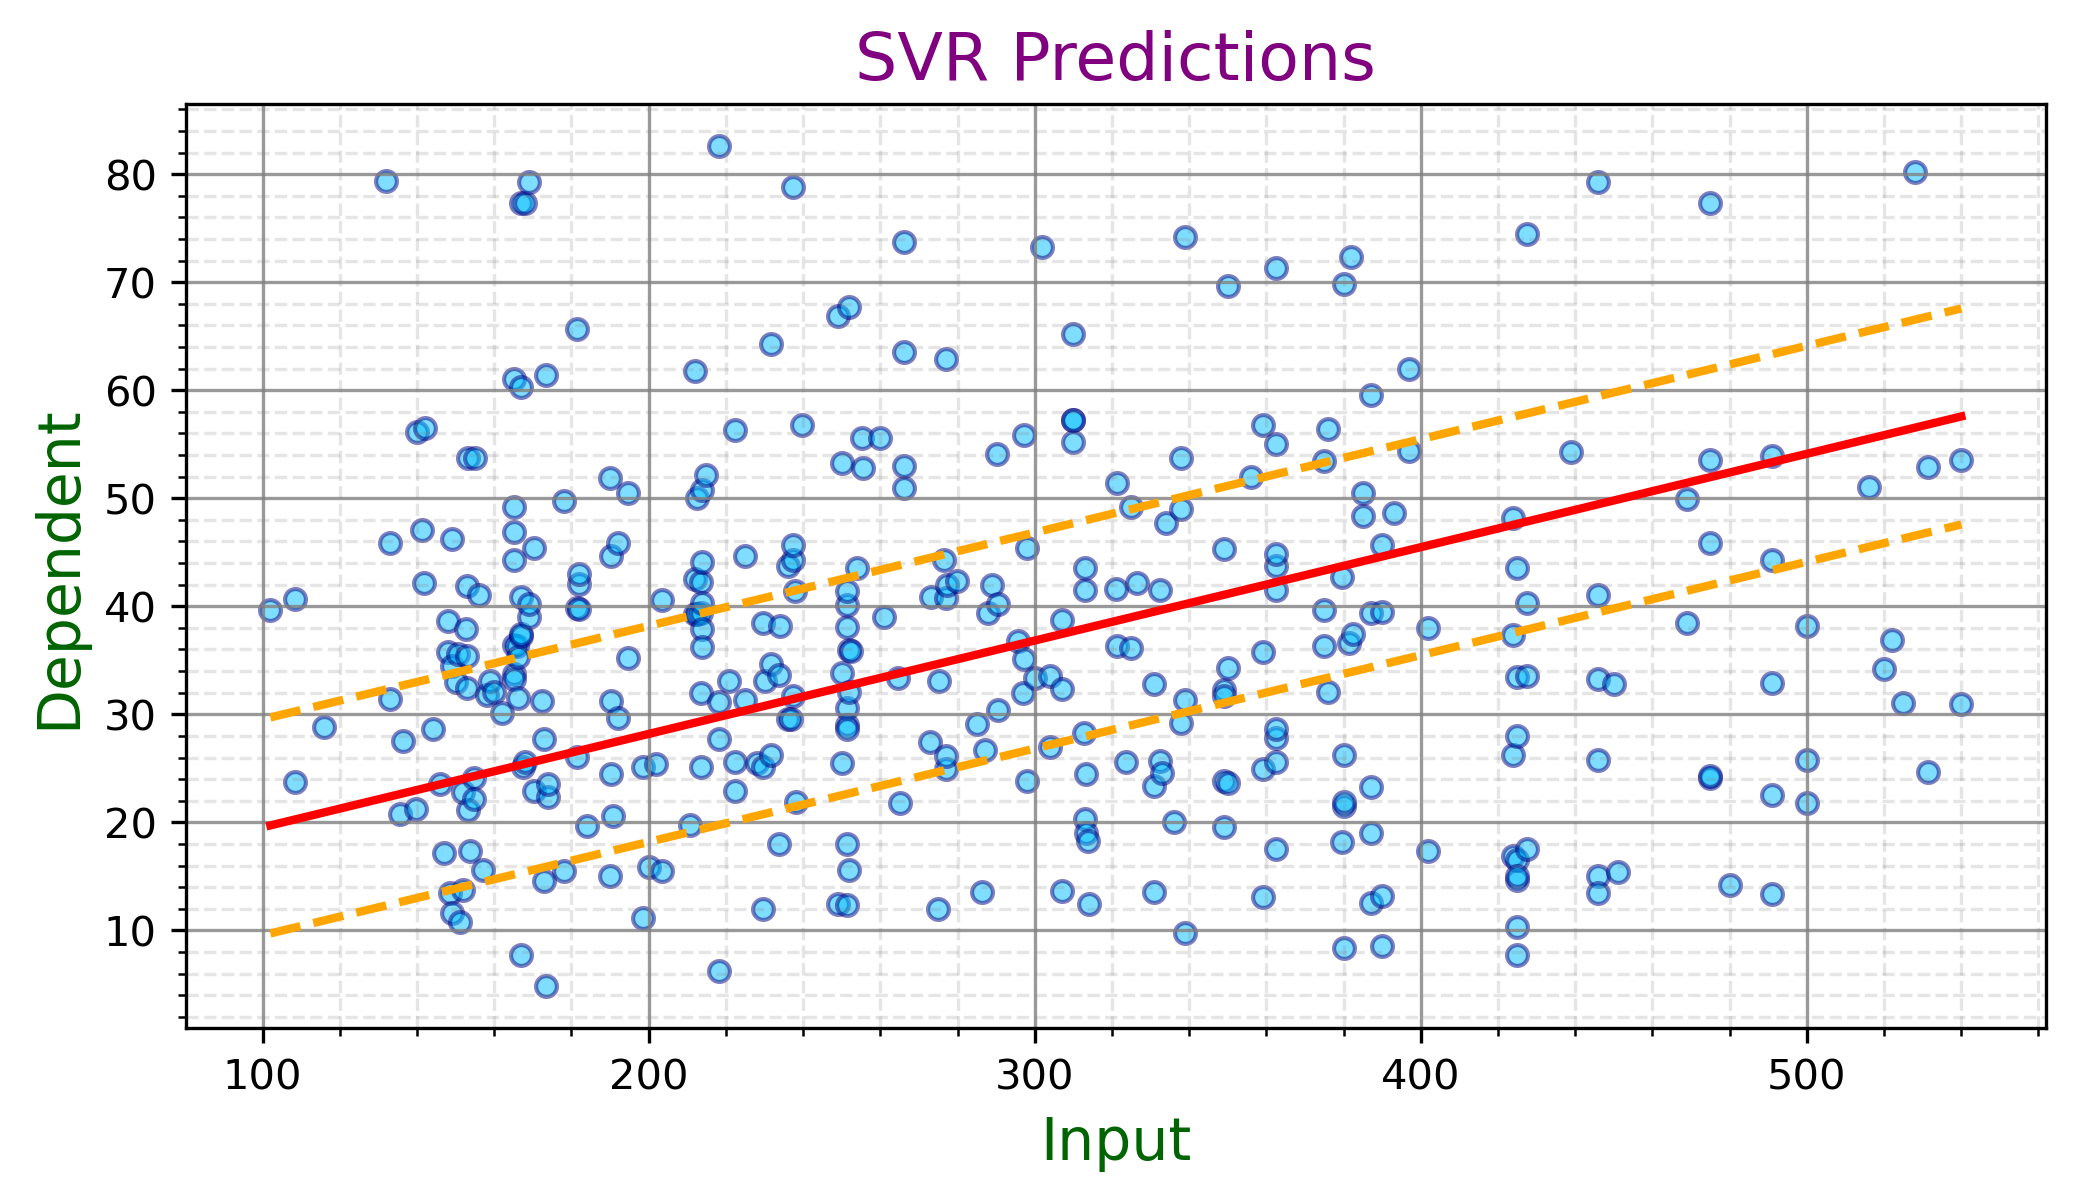

In [44]:
svr_results(X_test,y_test,model_svr2)

In [45]:
# the percentage of data within the band
100*np.sum(np.abs(y_test - model_svr2.predict(X_test))<eps)/len(y_test)

49.41860465116279

In [47]:
eps3 = 20
model_svr3 = SVR(kernel='poly', degree=3, epsilon=eps3,C=1)
model_svr3.fit(X_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'poly'
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",20
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [48]:
X_test.ravel().argsort()

array([ 56, 237,  89, 117, 313, 338, 205, 268, 187, 212,  48,  71, 125,
        86, 184, 179, 234, 158,  98,   1,  74,  23, 232,  58,  19, 314,
        51, 264, 216, 259, 284, 272, 296,  62, 302, 219, 238, 218, 297,
       130, 288,  70, 287,  78, 134, 262, 271, 275,  37,  41, 294,  28,
       309, 257, 165, 328, 250, 263,  76, 156,  40, 317, 300, 295,  15,
       119,  25, 332,  44, 324, 266, 136,  32, 138, 235, 336, 104,  24,
       254,  66, 152, 289,  88, 122, 236, 186, 245, 282, 203, 304, 114,
       270, 230,  45, 303, 180,  16, 283, 127,  85, 334, 243, 251, 147,
       101, 329, 174, 160, 221,  34, 193, 285, 155, 194, 286, 327, 161,
       176, 290, 173, 315,  22,   2, 217, 293,  94, 265,  73, 239, 177,
        53, 318,  91, 269,  27,  36, 105, 107, 228, 159, 319,  43, 112,
       131, 260, 299,  97,  14,  80, 340, 181,   0,  90,  46, 178,  87,
       253, 214, 102,   7, 201, 199,  83,  26, 171, 204, 151,  42,  75,
        29, 231, 213, 325,  11, 106, 190, 100, 244, 326, 242, 33

C: 1
Epsilon: 20
R2 = 0.19
MSE = 210.52
Percentage within Epsilon = 84.01%


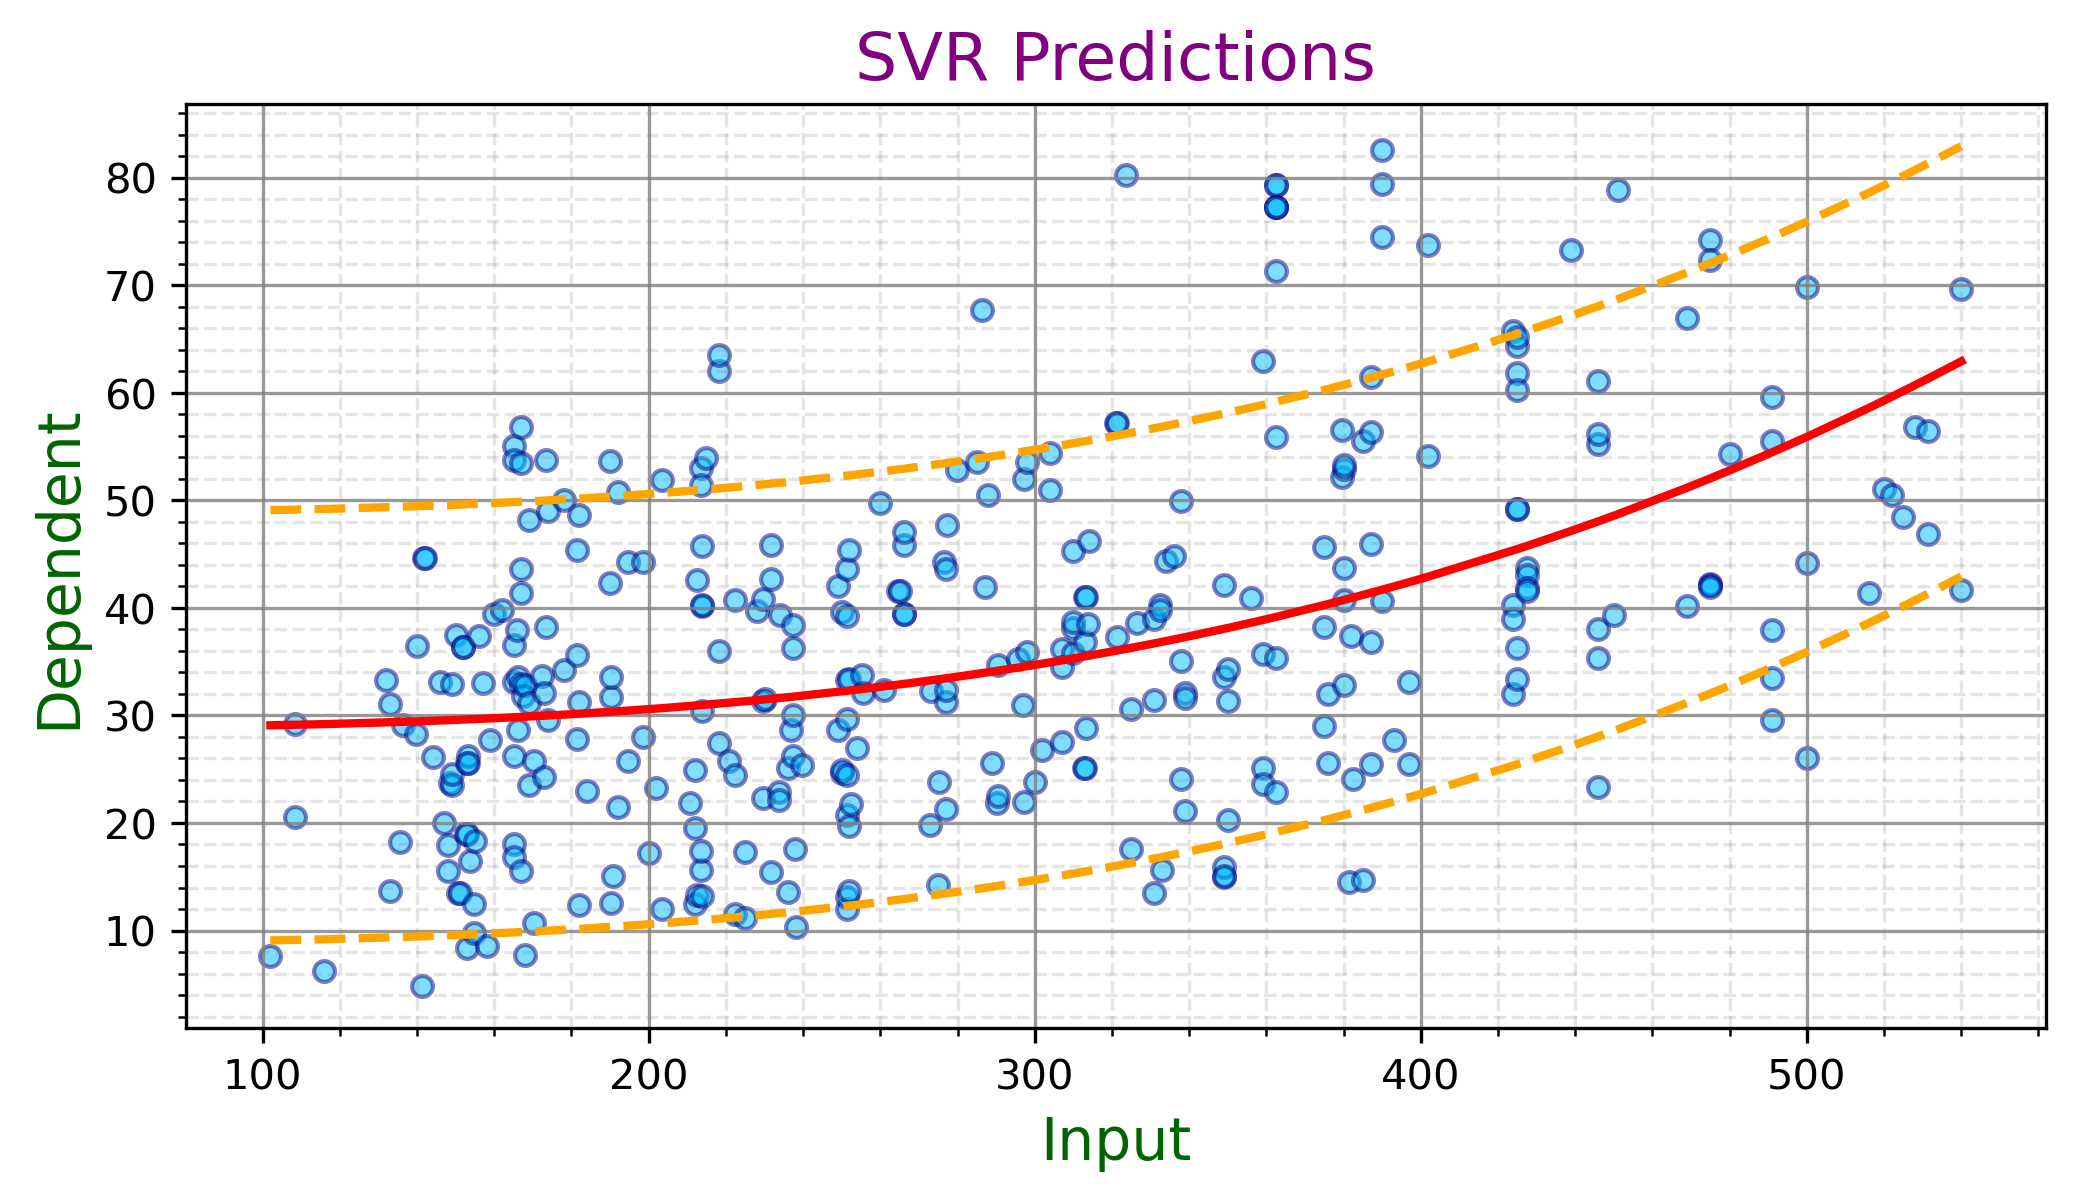

In [49]:
svr_results(X_test[X_test.ravel().argsort()],y_test[X_test.ravel().argsort()],model_svr3)

## What is the meaning of the Band? - Simulation Study

In [50]:
# example with fictitious data
x = np.linspace(10,30,100)
y = 2*x-1 + 2*np.random.normal(0,1,100)

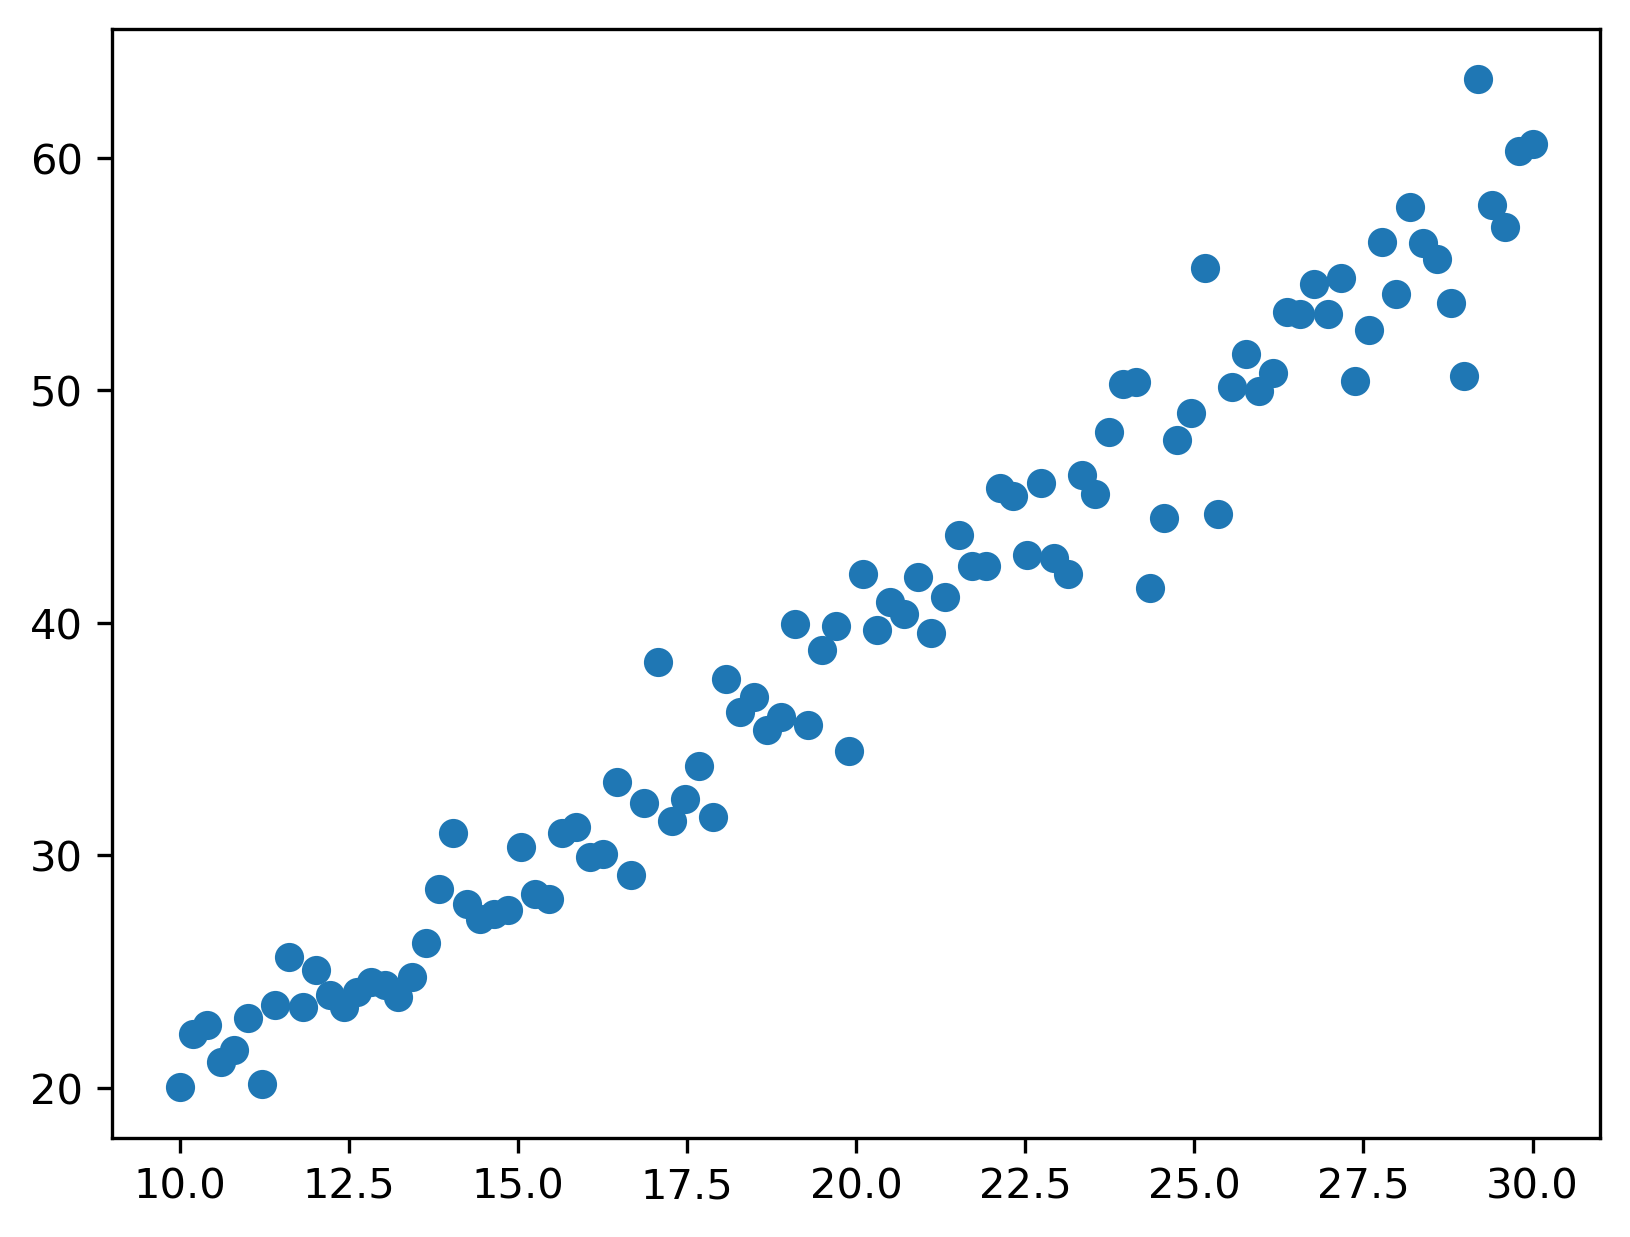

In [51]:
plt.scatter(x,y)
plt.show()

C: 5
Epsilon: 3
R2 = 0.96
MSE = 4.85
Percentage within Epsilon = 87.00%


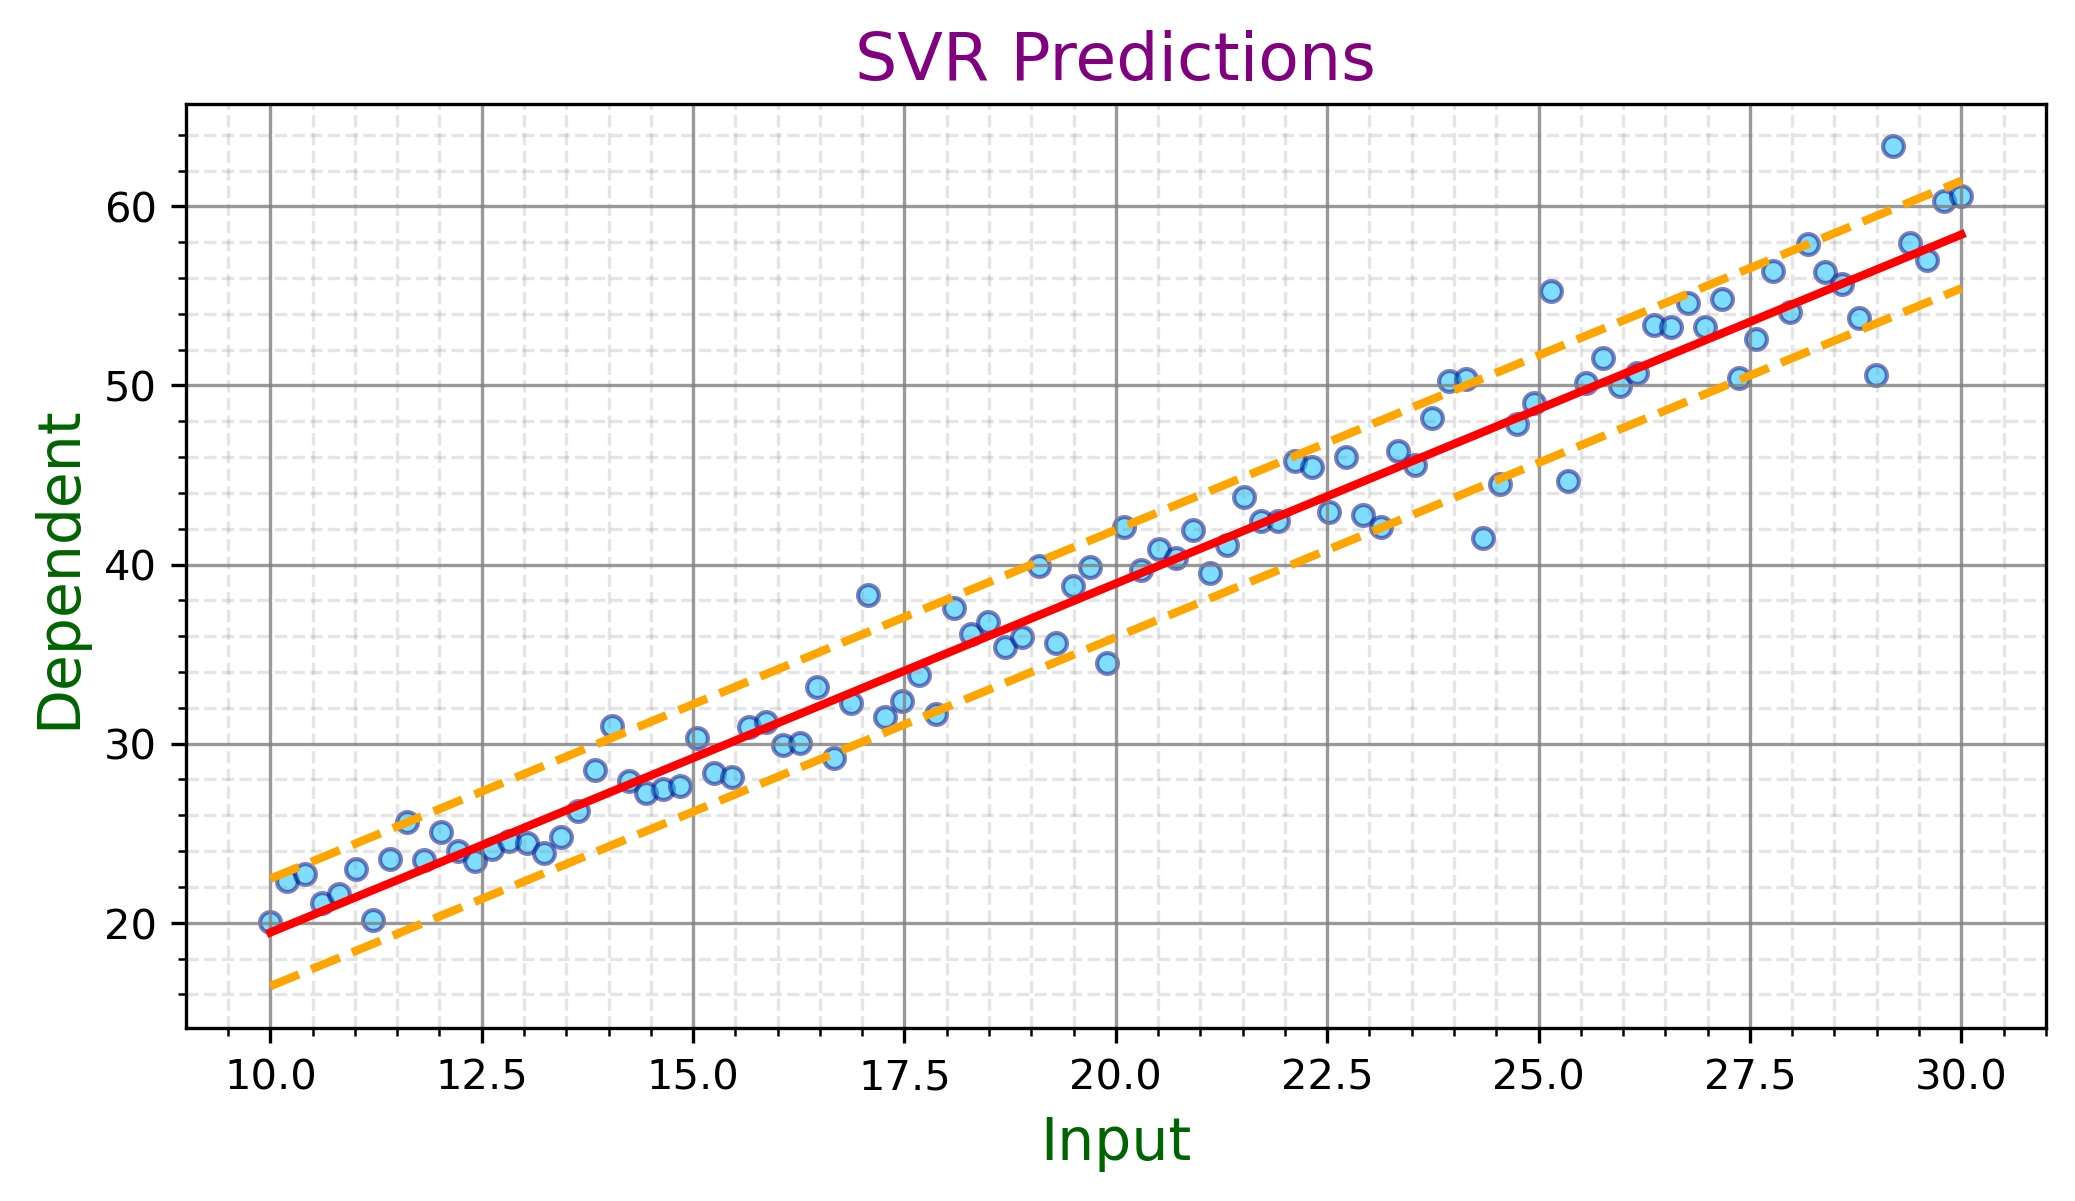

In [58]:
model_svr4 = SVR(kernel='linear', epsilon=3, C=5)
model_svr4.fit(x.reshape(-1,1),y)
svr_results(x.reshape(-1,1),y,model_svr4)

C: 5
Epsilon: 3
R2 = 0.95
MSE = 6.18
Percentage within Epsilon = 79.00%


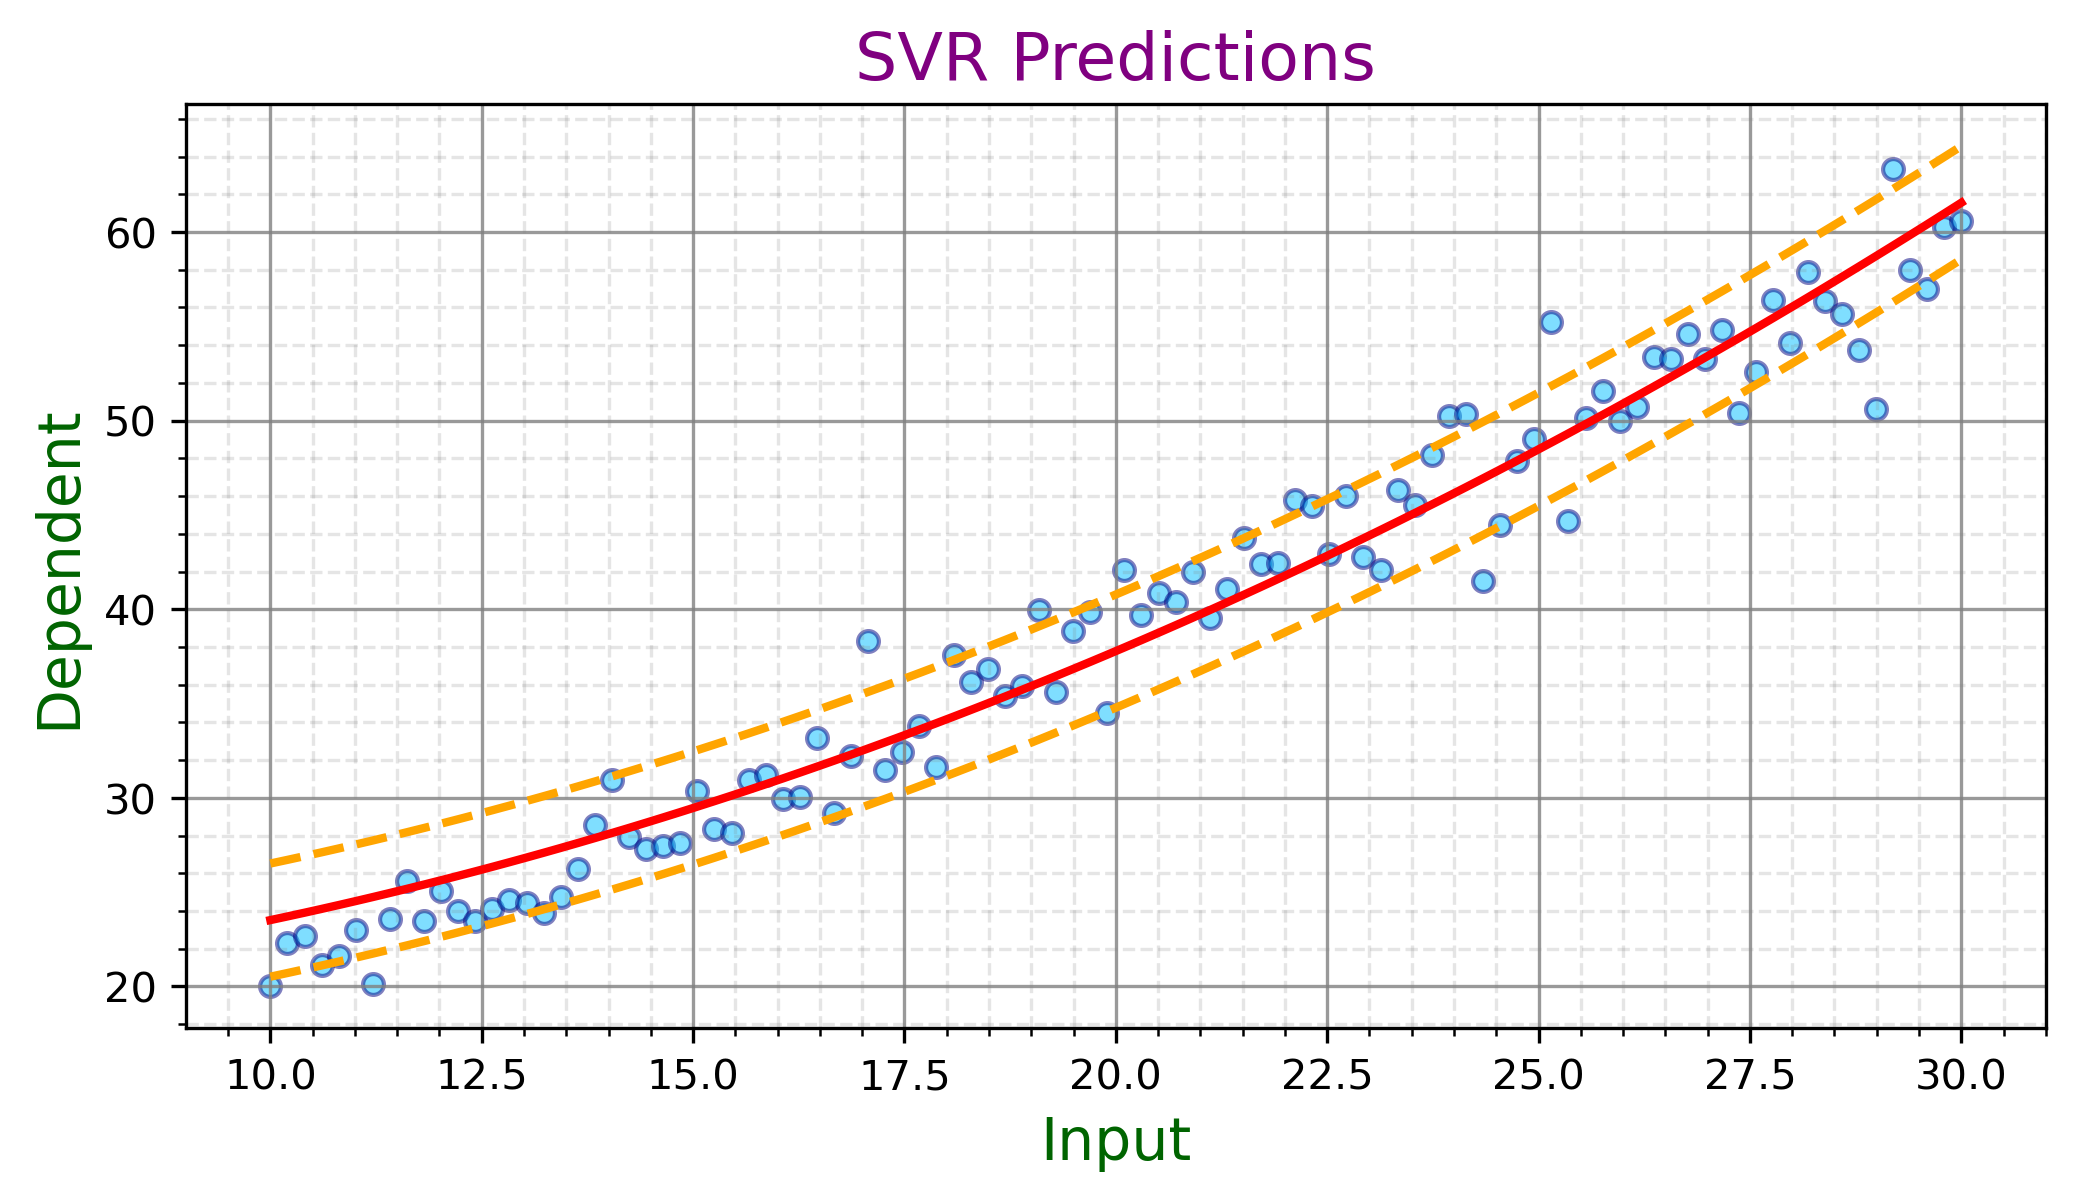

In [59]:
model_svr5 = SVR(kernel='poly', degree=2,epsilon=3,C=5)
model_svr5.fit(x.reshape(-1,1),y)
svr_results(x.reshape(-1,1),y,model_svr5)

## Standarlize Effect

In [67]:
scale = StandardScaler()

In [68]:
xtrain_scaled = scale.fit_transform(X_train)
xtest_scaled = scale.transform(X_test)

In [69]:
model_svr2.fit(xtrain_scaled,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",1
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",2
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",10
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [70]:
100*np.sum(np.abs(y_test - model_svr2.predict(xtest_scaled))<eps)/len(y_test)

49.41860465116279

C: 2
Epsilon: 10
R2 = 0.26
MSE = 211.51
Percentage within Epsilon = 46.79%


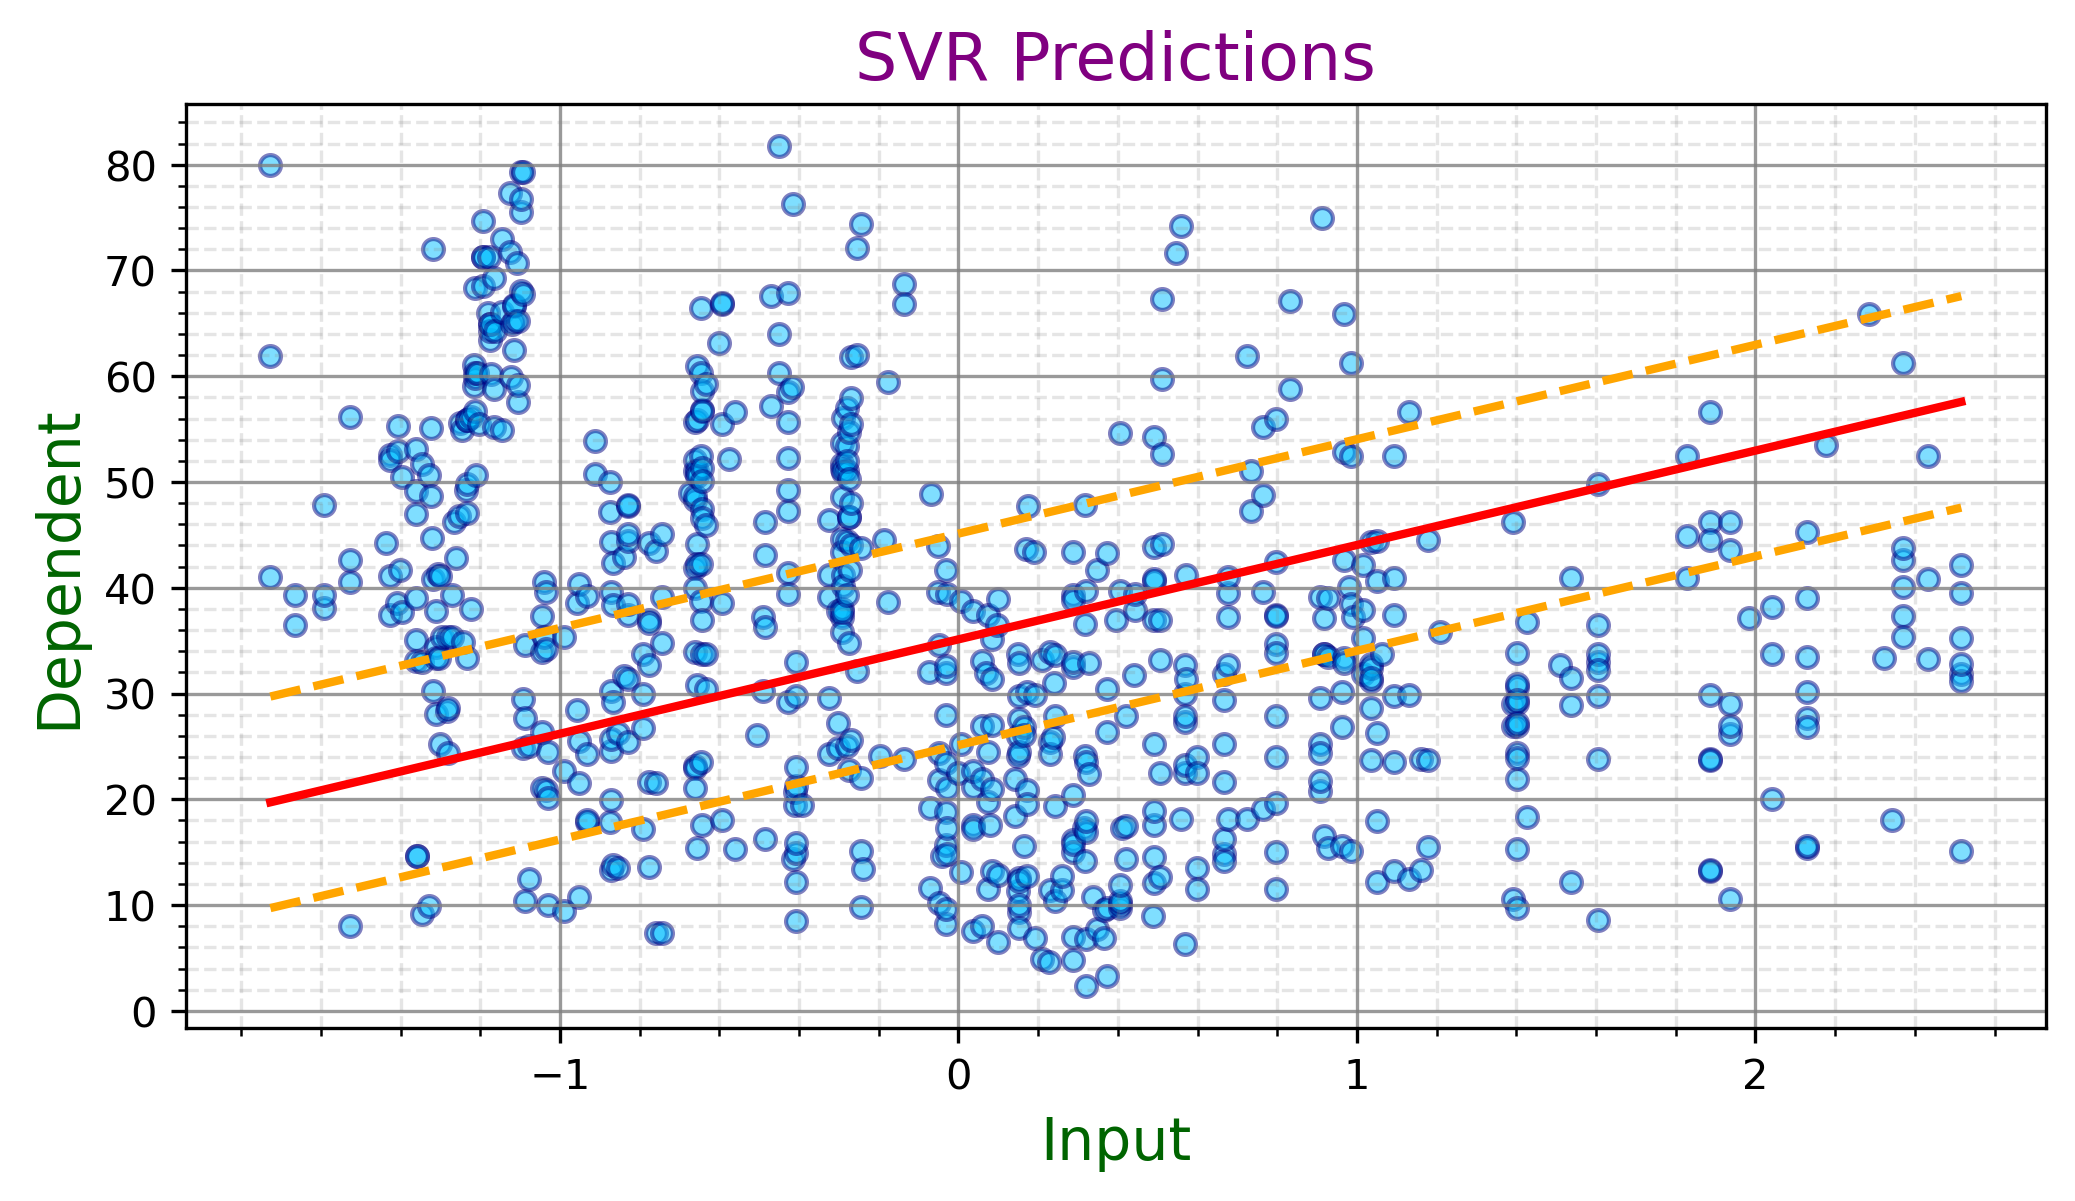

In [71]:
svr_results(xtrain_scaled,y_train,model_svr2)

## SVR with polynomial kernel

In [77]:
eps = 10
model_svr_poly = SVR(kernel='poly',degree=3,C=1.5,epsilon=eps)

In [78]:
model_svr_poly.fit(X_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'poly'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.5
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",10
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


C: 1.5
Epsilon: 10
R2 = 0.18
MSE = 213.87
Percentage within Epsilon = 48.84%


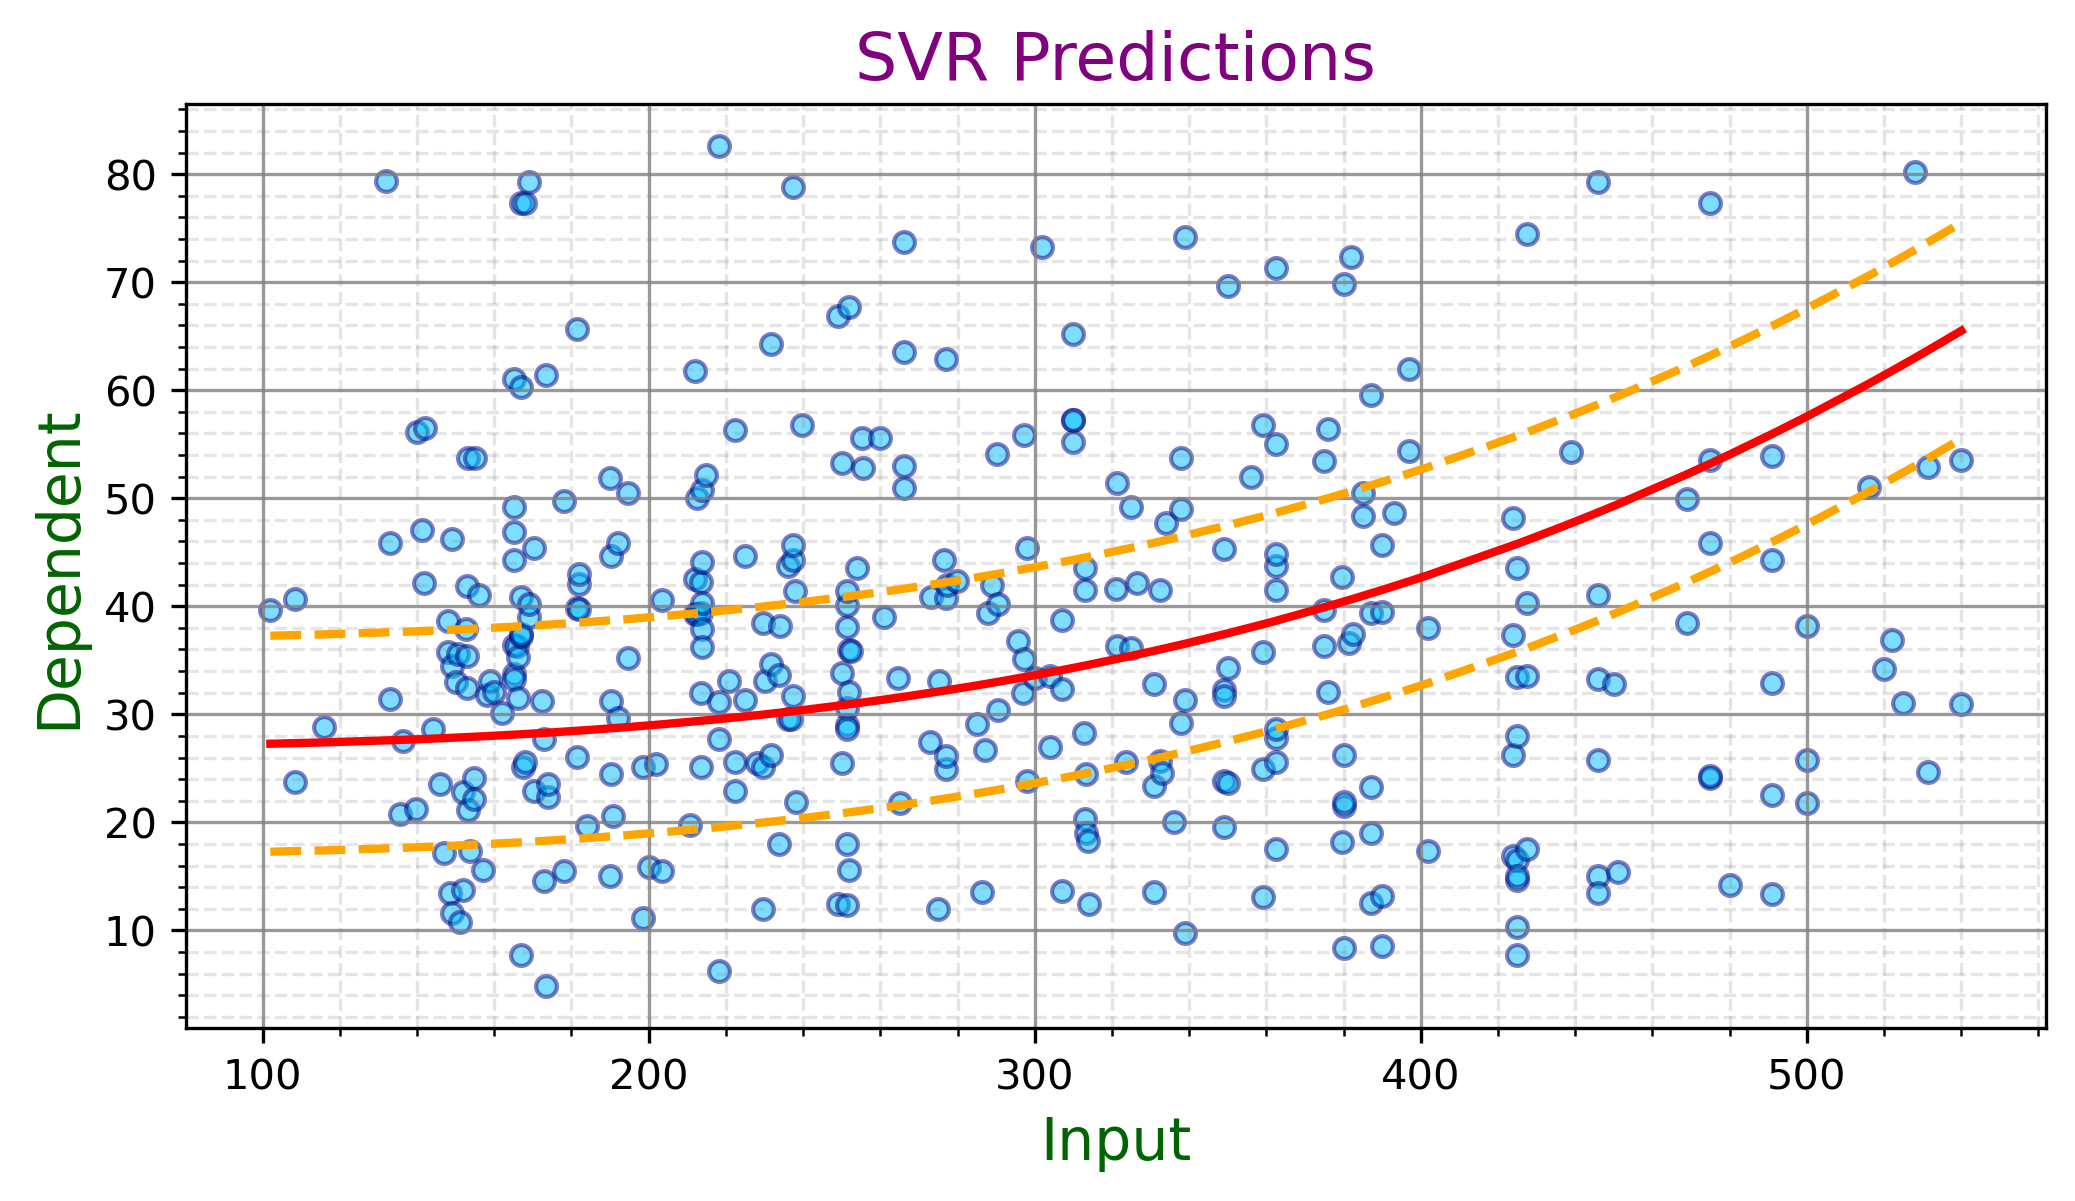

In [79]:
svr_results(X_test,y_test,model_svr_poly)

Thoughts: maybe this is not a great model and perhaps we can improve it by increasing the model complexity and/or changing the hyper-parameters.

## SVM with multiple features

In [80]:
# we would like to use all the different input variables
X_train, X_test, y_train, y_test = train_test_split(data.loc[:,'cement':'age'].values, data['strength'].values, test_size=0.3, random_state=123)

In [81]:
scale = StandardScaler()

In [82]:
xtrain_scaled = scale.fit_transform(X_train)

In [83]:
xtest_scaled = scale.transform(X_test)

In [85]:
# let's make a multivariate SVR model
model_svr2.fit(xtrain_scaled,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",1
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",2
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",10
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [86]:
model_svr2.score(xtest_scaled,y_test)

0.5745383385555357

## SVC 2D Classification

In [107]:
from sklearn import svm
from celluloid import Camera
from tqdm import tqdm

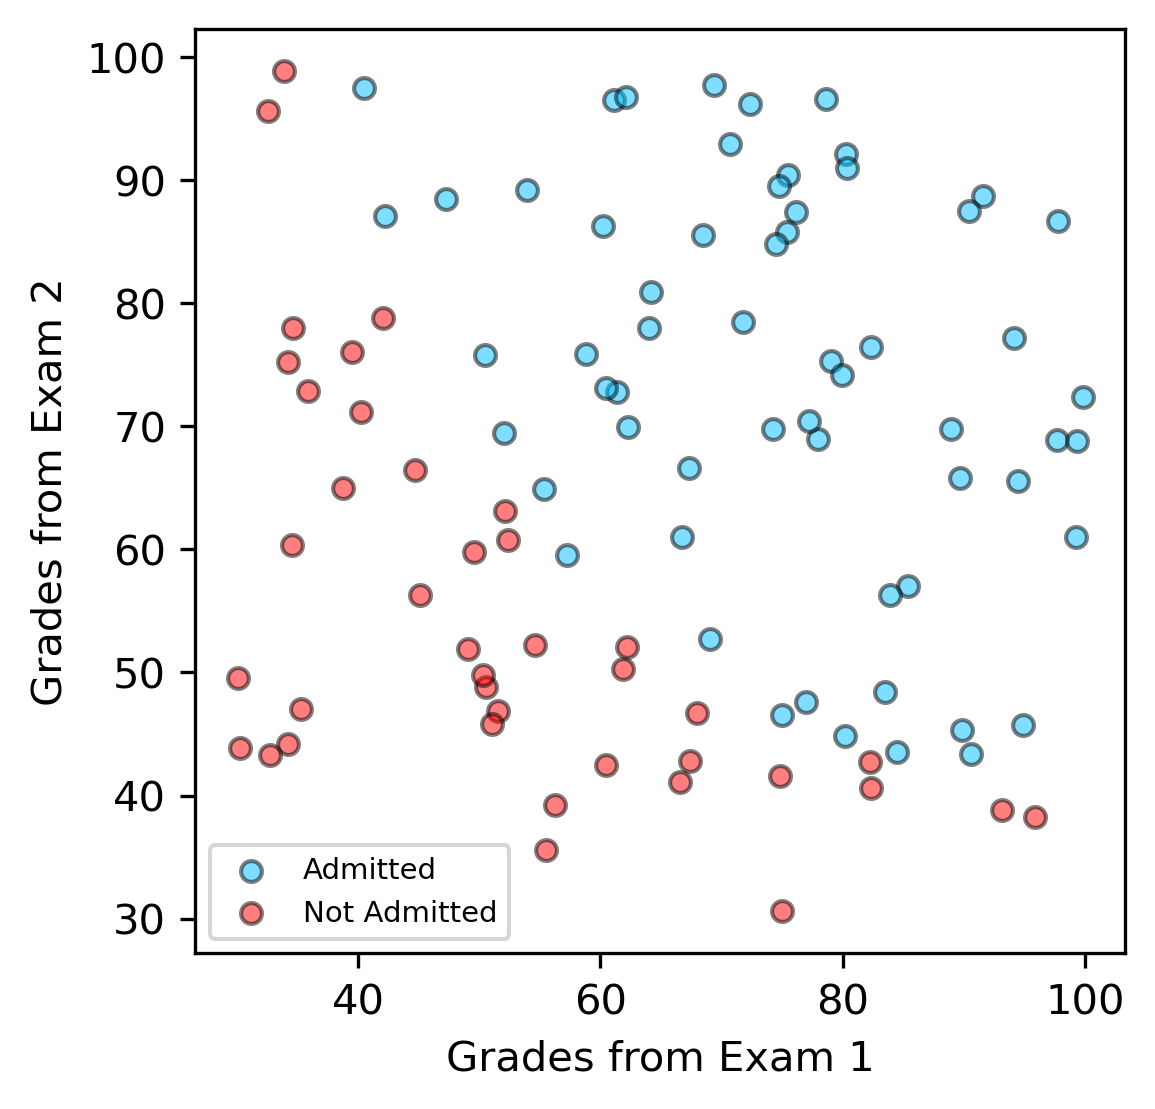

In [97]:
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score, confusion_matrix as CM


# function definitions
def load_data(path, header):
    marks_df = pd.read_csv(path, header=header)
    return marks_df

data = pd.read_csv('https://github.com/yanhai-xiong/DATA301-AML/blob/main/Data%20Sets/example_data_classification.csv?raw=true', header=None)

# X = feature values, all the columns except the last column
x = data.iloc[:, :-1]

# y = target values, last column of the data frame
y = data.iloc[:, -1]

# filter out the applicants that got admitted
admitted = data.loc[y == 1]

# filter out the applicants that din't get admission
not_admitted = data.loc[y == 0]

# plots
plt.figure(figsize=(4,4))
plt.scatter(admitted.iloc[:, 0], admitted.iloc[:, 1],color ='deepskyblue', s=25, label='Admitted',ec='k',alpha=0.5)
plt.scatter(not_admitted.iloc[:, 0], not_admitted.iloc[:, 1],color='red', s=25, ec='k',alpha=0.5,label='Not Admitted')
plt.xlabel("Grades from Exam 1")
plt.ylabel("Grades from Exam 2")
plt.legend(fontsize=7)
plt.show()

The accuracy is :0.99


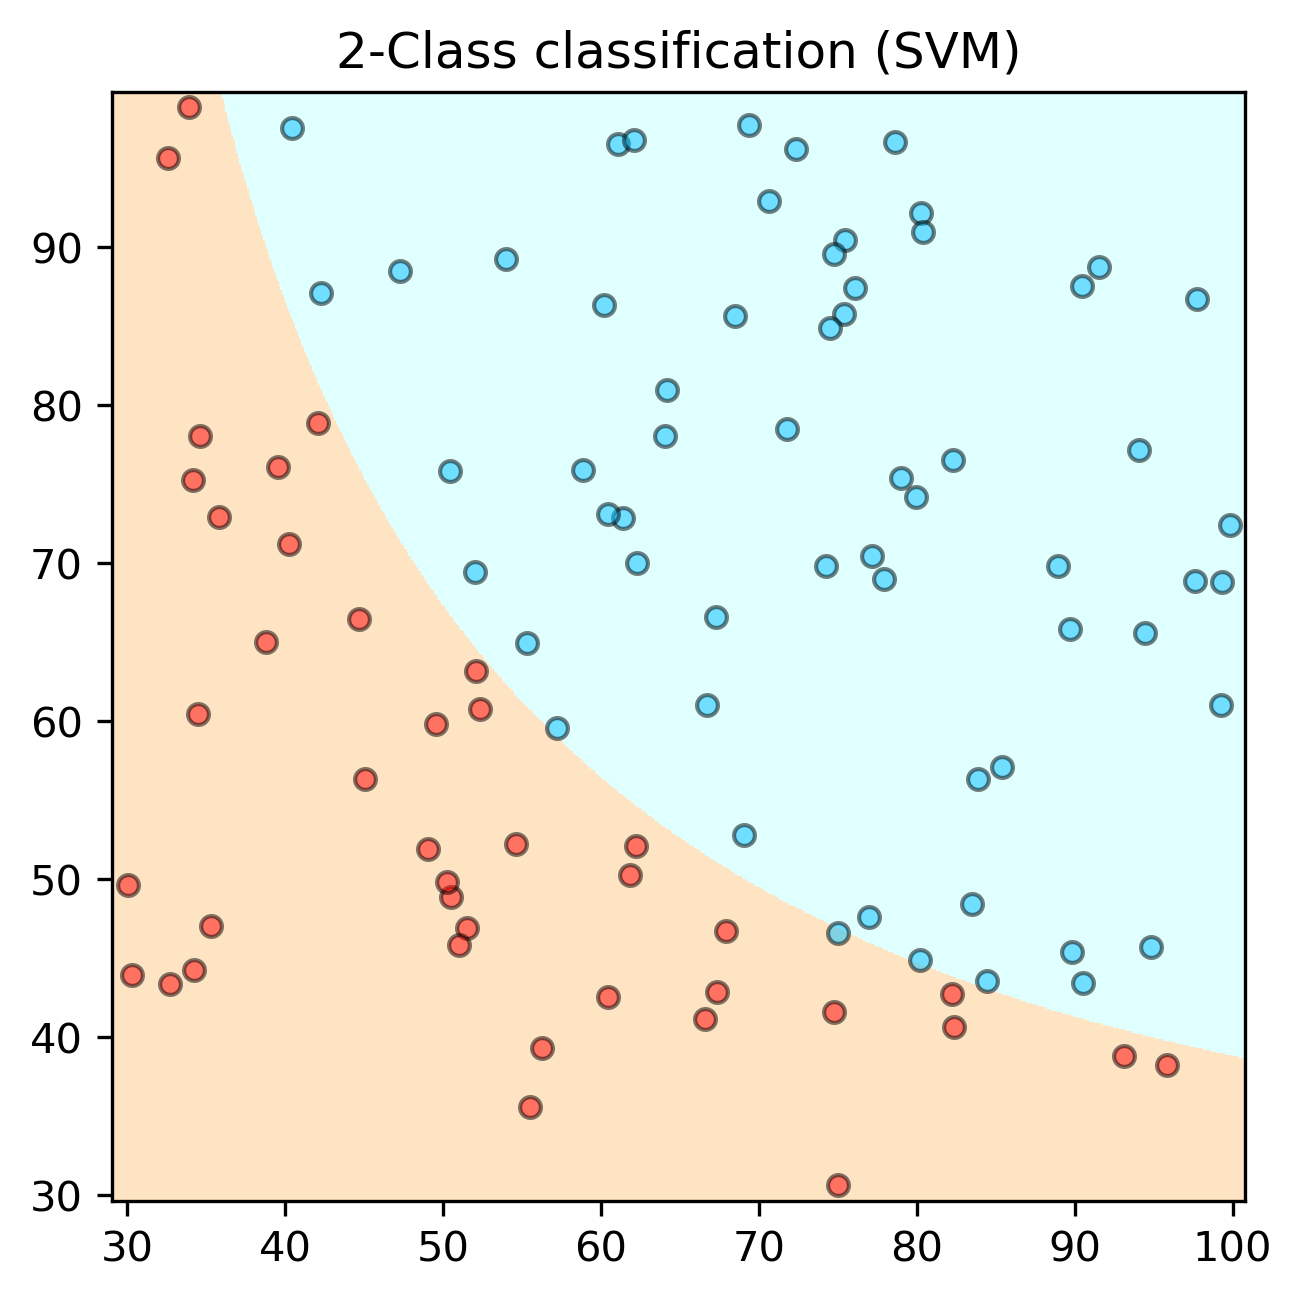

In [101]:
# here we have an application of SVM
h = .1 # step size in the grid of points
cmap_light = ListedColormap(['bisque', 'lightcyan'])
cmap_bold = ListedColormap(['red', '#00FF00'])

# Plot the decision boundary. For that, we will assign a color to each
# point in the mesh [x_min, x_max]x[y_min, y_max].
x_min, x_max = x.values[:, 0].min() - 1, x.values[:, 0].max() + 1
y_min, y_max = x.values[:, 1].min() - 1, x.values[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# svc = svm.SVC(kernel='rbf', C=1,gamma=0.001,probability=True).fit(x, y)
svc = svm.SVC(kernel='poly', degree=2,C=1,probability=True).fit(x, y)
Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)

print(f'The accuracy is :{svc.score(x,y)}')
fig, ax = plt.subplots()
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# Plot also the points
plt.scatter(admitted.iloc[:, 0], admitted.iloc[:, 1],  color ='deepskyblue', s=25, label='Admitted',ec='k',alpha=0.5)
plt.scatter(not_admitted.iloc[:, 0], not_admitted.iloc[:, 1],color ='red', s=25,ec='k',alpha=0.5, label='Not Admitted')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
ax.set_aspect('equal', 'box')
plt.title("2-Class classification (SVM)")

plt.show()

In [102]:
svc.score(x,y) # slight improvement over Logistic Regression

0.99

In [103]:
ranges = np.concatenate([np.linspace(0.5,0.001,200),np.repeat(0.001,100),np.linspace(0.001,0.5,200)])

100%|████████████████████████████████████████| 500/500 [09:50<00:00,  1.18s/it]


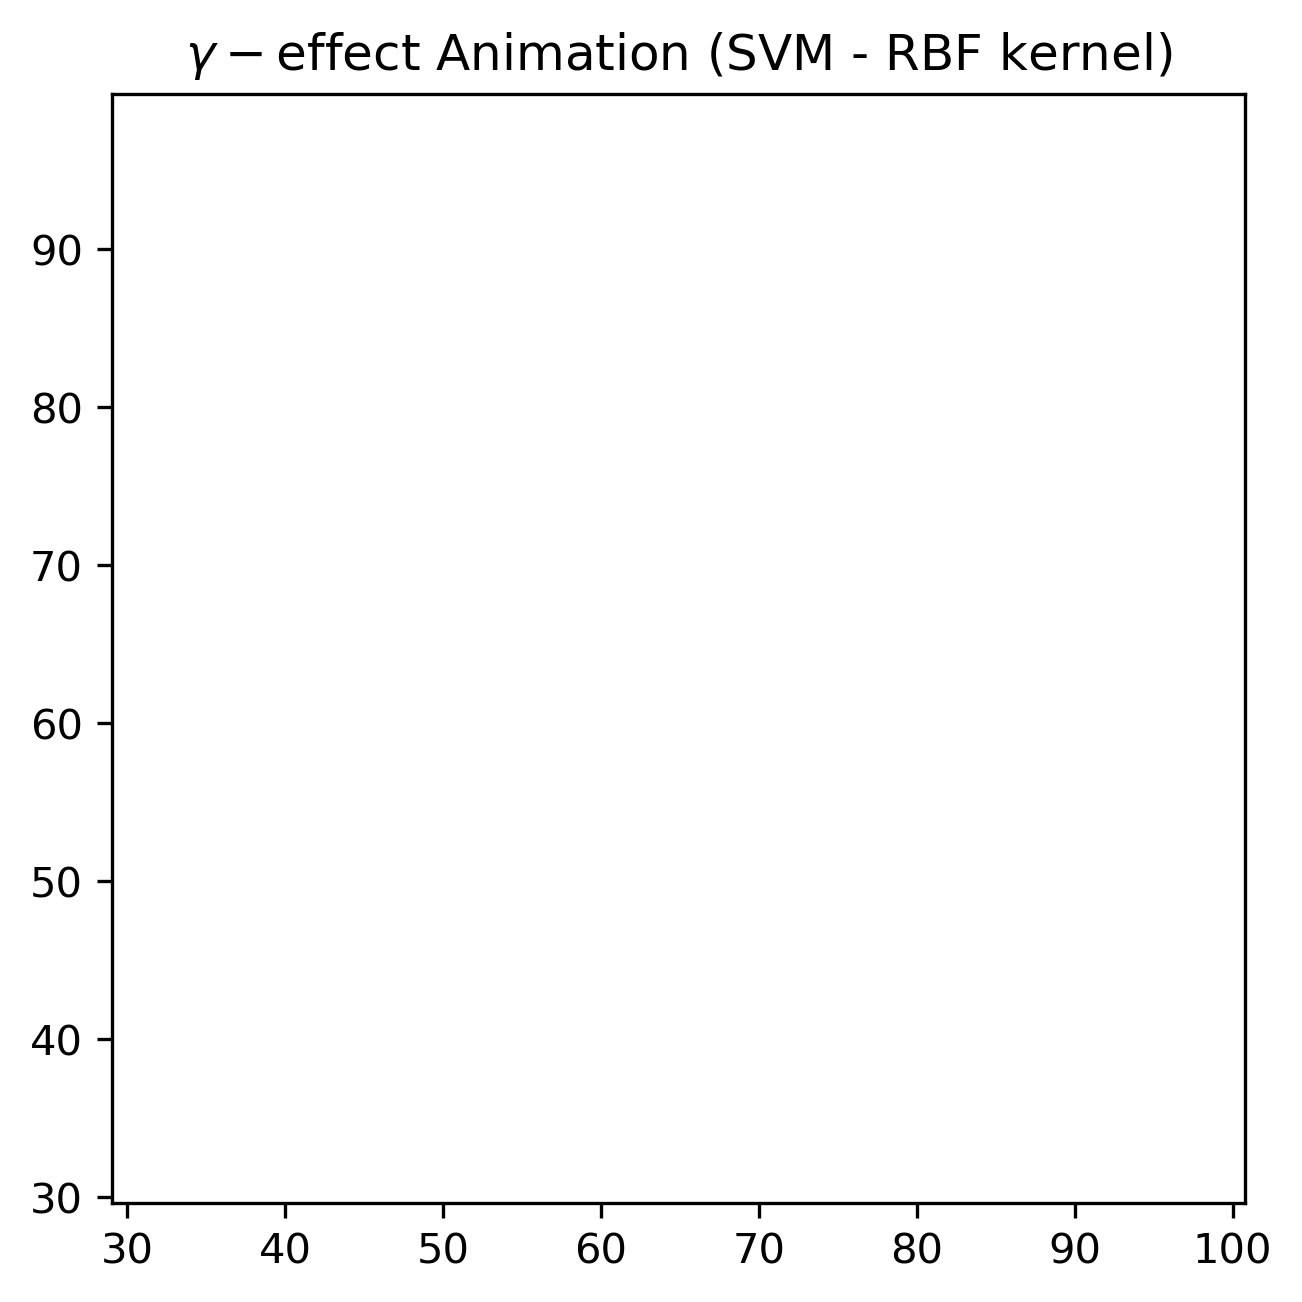

In [108]:
# animation
fig, ax = plt.subplots()
camera = Camera(fig)
for gamma in tqdm(ranges):
    svc = svm.SVC(kernel='rbf', C=1,gamma=gamma,probability=True).fit(x, y)
    Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)

    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    # Plot also the points
    plt.scatter(admitted.iloc[:, 0], admitted.iloc[:, 1],  color ='deepskyblue', s=25, label='Admitted',ec='k',alpha=0.5)
    plt.scatter(not_admitted.iloc[:, 0], not_admitted.iloc[:, 1],color ='red', s=25,ec='k',alpha=0.5, label='Not Admitted')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    ax.set_aspect('equal', 'box')
    plt.title(r"$\gamma-$effect Animation (SVM - RBF kernel)")
    camera.snap()
animation = camera.animate(interval = 24, repeat = True,
                           repeat_delay = 500)
animation.save('Gamma-effect animation.gif',writer = 'pillow',dpi=200)

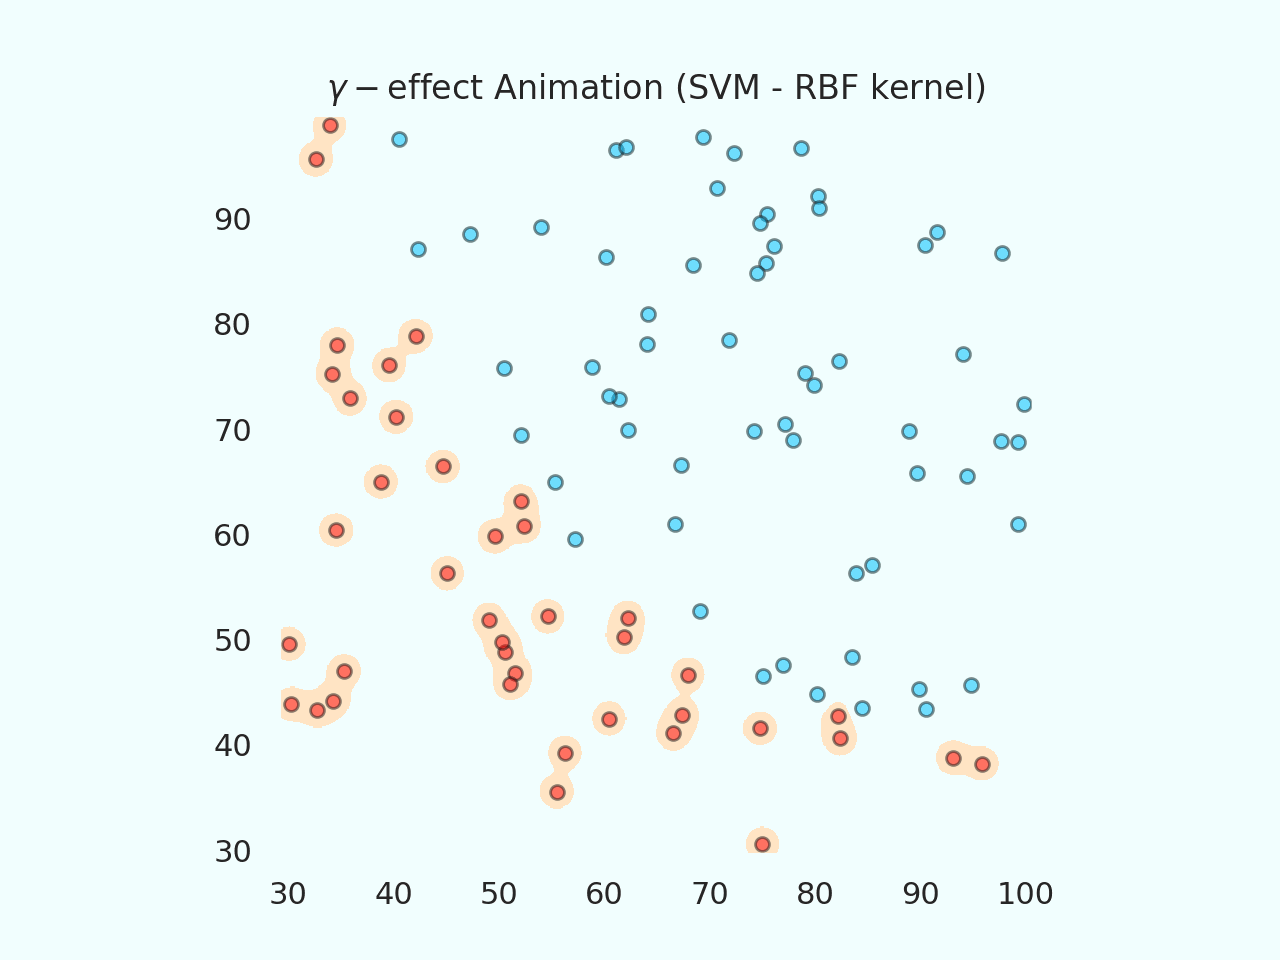

In [ ]:
Image(open('Gamma-effect animation.gif','rb').read())

In [ ]:
svc.score(x,y)

0.91

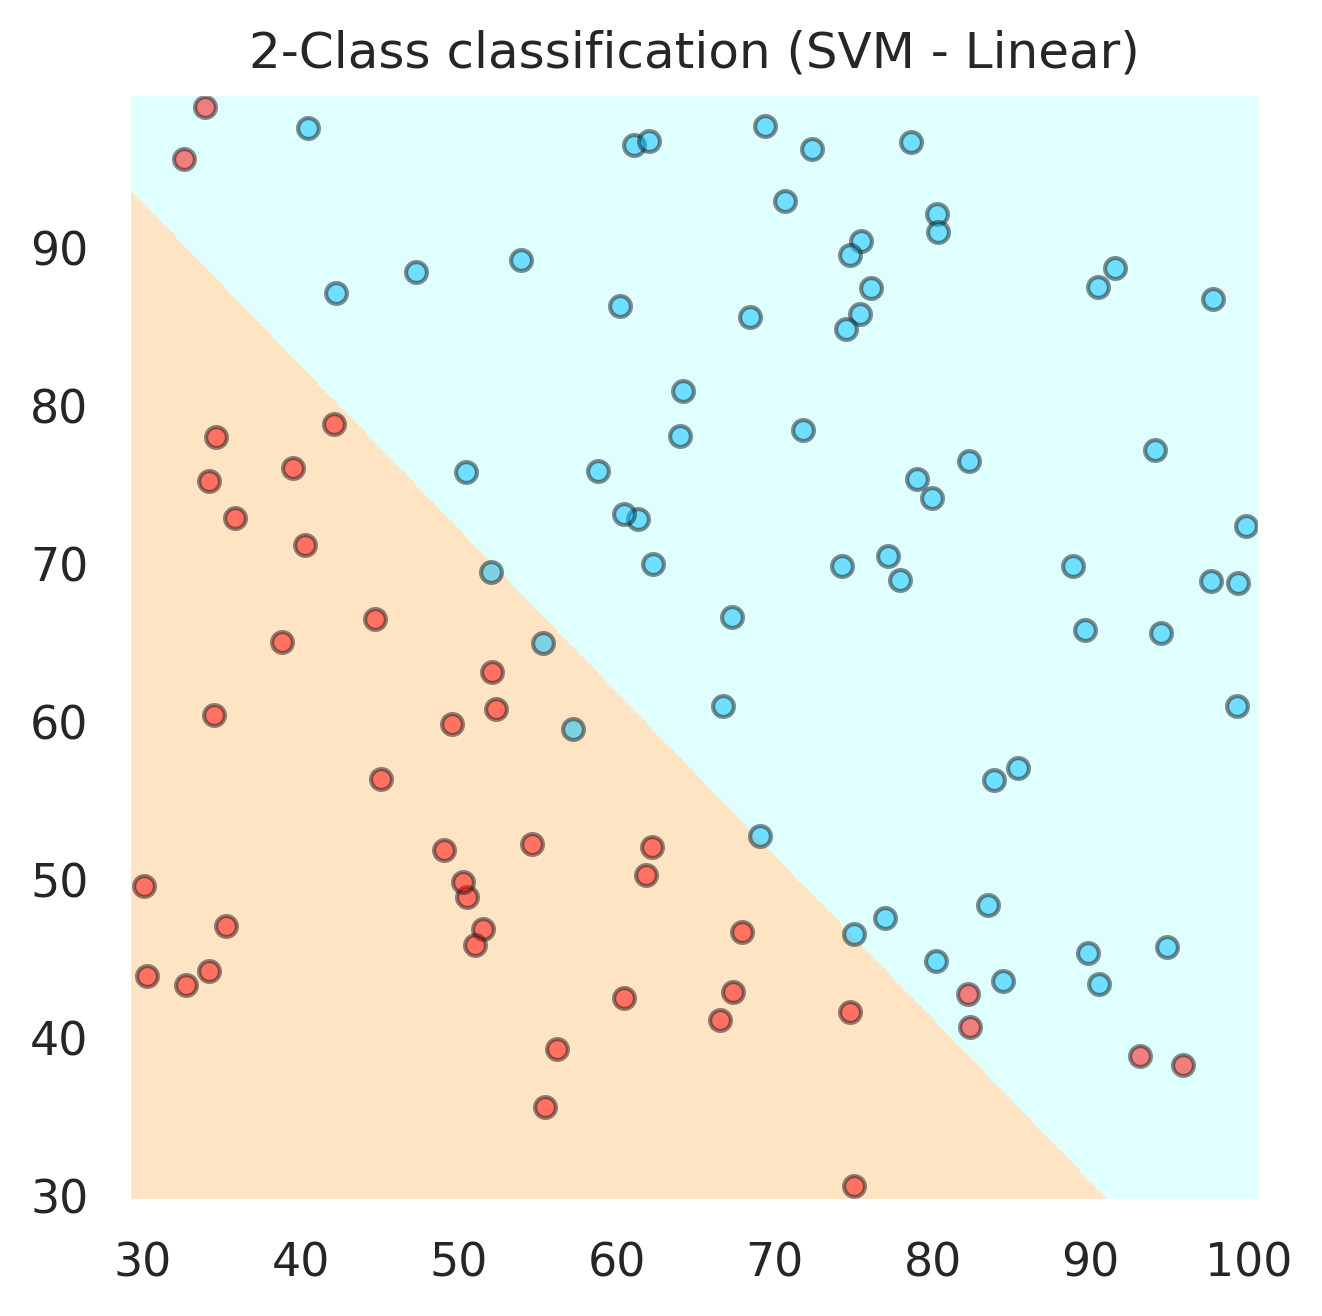

In [ ]:
svc_linear = svm.SVC(kernel='linear', C=1,gamma='auto',probability=True).fit(x, y)
Z = svc_linear.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
fig, ax = plt.subplots()
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# Plot also the points
plt.scatter(admitted.iloc[:, 0], admitted.iloc[:, 1],  color ='deepskyblue', s=25, label='Admitted',ec='k',alpha=0.5)
plt.scatter(not_admitted.iloc[:, 0], not_admitted.iloc[:, 1],color ='red', s=25,ec='k',alpha=0.5, label='Not Admitted')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
ax.set_aspect('equal', 'box')
plt.title("2-Class classification (SVM - Linear)")

plt.show()

In [ ]:
accuracy_score(y,svc_linear.predict(x))

0.91

In [ ]:
svc_linear.predict_proba([[70,67]])

array([[0.10848745, 0.89151255]])

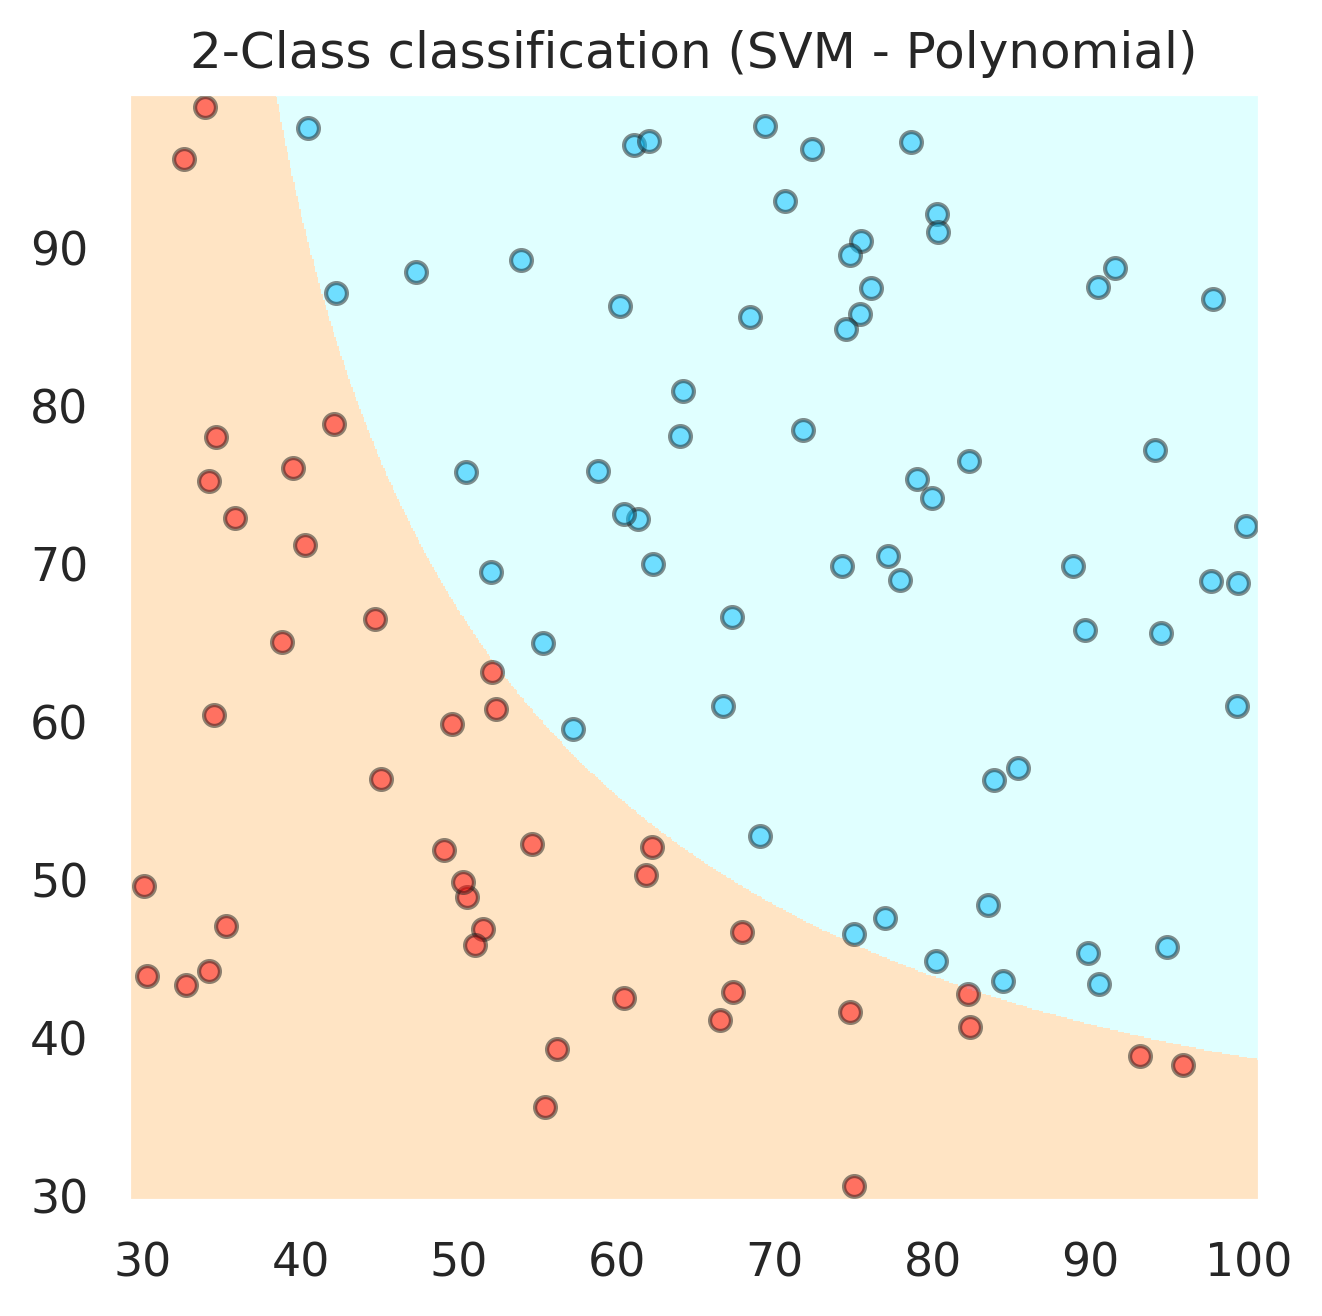

In [ ]:
svc_poly = svm.SVC(kernel='poly', C=20,probability=True,degree=2).fit(x, y)
Z = svc_poly.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
fig, ax = plt.subplots()
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# Plot also the points
plt.scatter(admitted.iloc[:, 0], admitted.iloc[:, 1],  color ='deepskyblue', s=25, label='Admitted',ec='k',alpha=0.5)
plt.scatter(not_admitted.iloc[:, 0], not_admitted.iloc[:, 1],color ='red', s=25,ec='k',alpha=0.5, label='Not Admitted')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
ax.set_aspect('equal', 'box')
plt.title("2-Class classification (SVM - Polynomial)")

plt.show()

In [ ]:
accuracy_score(y,svc_poly.predict(x))

1.0

In [ ]:
svc_poly.predict_proba([[50,50]])

array([[0.95760218, 0.04239782]])

In [ ]:
svc_poly.predict_proba([[84,40]])

array([[0.77501341, 0.22498659]])